# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


from sklearn.linear_model import LogisticRegression

# DL libs
import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from scikeras.wrappers import KerasClassifier


# keep "adamw" in the grid, pin TF in requirements.txt (e.g., tensorflow>=2.11) or note the version.
import os
from itertools import product

import pickle

import re

from typing import List, Tuple, Optional

D:\OneDrive\Documents\anaconda\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
D:\OneDrive\Documents\anaconda\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
D:\OneDrive\Documents\anaconda\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibili

I (Keith) use sklearn: 1.4.2 imblearn: 0.12.3

In [2]:
import sklearn, imblearn
print("sklearn:", sklearn.__version__, "imblearn:", imblearn.__version__)

sklearn: 1.4.2 imblearn: 0.12.3


# Keep this random state, hopefully for reproducibility

Im afraid that this alone does not guarantee deterministic random sampling for batch gradient descent

In [3]:
RANDOM_STATE=42
tf.random.set_seed(RANDOM_STATE)

# Splitting functions and custom IQRClipper

In [4]:
# Convert one-hot cohort flags into a single label
def label_subcohort(df):
    df = df.copy()
    df["cohort"] = np.select(
        [
            df["is_mi"] == 1,
            df["is_pcr"] == 1,
            df["is_cbs"] == 1
        ],
        ["MI", "PCI", "CABG"],
        default="Other"
    )
    return df

# 1) collapse race to a few stable bins
def collapse_race(r):
    if pd.isna(r): return "UNKNOWN/OTHER"
    r = str(r).upper()
    if r.startswith("WHITE"): return "WHITE"
    if r.startswith("BLACK"): return "BLACK"
    if r.startswith("ASIAN"): return "ASIAN"
    if "HISPANIC" in r:        return "HISPANIC"
    if "PORTUGUESE" in r:      return "PORTUGUESE"
    if "SOUTH AMERICAN" in r:  return "HISPANIC"  # sensible merge
    if "PACIFIC ISLANDER" in r:return "PACIFIC"
    if r in {"OTHER","UNKNOWN","UNABLE TO OBTAIN","PATIENT DECLINED TO ANSWER",
             "MULTIPLE RACE/ETHNICITY","AMERICAN INDIAN/ALASKA NATIVE",
             "WHITE - OTHER EUROPEAN","WHITE - EASTERN EUROPEAN","WHITE - RUSSIAN",
             "WHITE - BRAZILIAN","BLACK/CAPE VERDEAN","BLACK/CARIBBEAN ISLAND"}:
        return "UNKNOWN/OTHER"
    return "UNKNOWN/OTHER"

def build_subject_strata(df: pd.DataFrame,
                         min_bin_size: int = 5,
                         outcome_col: str = "y",
                         cohort_col: str = "cohort",
                         race_col: str = "race"):
    
    g = df.copy()
    
    g["race_collapsed"] = g[race_col].map(collapse_race)

    # Make a *stable* per-subject cohort label.
    # Option A: majority cohort across their stays
    subj_mode_cohort = (
        g.groupby(["subject_id", cohort_col]).size()
         .reset_index(name="n")
         .sort_values(["subject_id","n"], ascending=[True, False])
         .drop_duplicates("subject_id")[["subject_id", cohort_col]]
         .rename(columns={cohort_col: "cohort_major"})
    )

    # Outcome as a subject-level flag (any positive stay)
    subj_y = (
        g.groupby("subject_id")[outcome_col]
         .max()
         .rename("y_any")
         .reset_index()
    )

    # Subject-level collapsed race: mode
    subj_race = (
        g.groupby(["subject_id","race_collapsed"]).size()
         .reset_index(name="n")
         .sort_values(["subject_id","n"], ascending=[True, False])
         .drop_duplicates("subject_id")[["subject_id","race_collapsed"]]
    )

    subj = (
        subj_mode_cohort.merge(subj_race, on="subject_id")
                        .merge(subj_y, on="subject_id")
    )

    # Compose strata label
    subj["strata"] = (
        subj["cohort_major"].astype(str) + "|" +
        subj["race_collapsed"].astype(str) + "|" +
        subj["y_any"].astype(str)
    )

    # Merge rare strata into a single bin to avoid stratify errors
    counts = subj["strata"].value_counts()
    rare = counts[counts < min_bin_size].index
    subj.loc[subj["strata"].isin(rare), "strata"] = "OTHER_BIN"

    return subj[["subject_id","strata"]]

def remove_outlier_drop_gapdays_and_split(df_all: pd.DataFrame,
                                          val_and_test_size: float = 0.30,
                                          random_state: int = 42,
                                          outcome_col: str = "y",
                                          cohort_col: str = "cohort",
                                          race_col: str = "race"):
    """
    - Hard-remove obvious data-entry outliers.
    - Drop prev_gap_days (non-imputable by design).
    - Stratified split by *subject_id* using a patient-level strata label
      (cohort_major × collapsed race × y_any), with rare bins merged.
    - Returns row-level train/val/test DataFrames.
    """
    
    
    df = df_all.copy()
    if "cohort" not in df.columns:
        df = label_subcohort(df)

    # 0) hard outliers + drop prev_gap_days
    df = df[(df["glucose_mean"] < 999999) & (df["wbc_last_24h"] < 400)]
    if "prev_gap_days" in df.columns:
        df = df.drop(columns=["prev_gap_days"])

    # 1) build subject-level strata
    subj = build_subject_strata(df, min_bin_size=5,
                                outcome_col=outcome_col,
                                cohort_col=cohort_col,
                                race_col=race_col)

    # 2) split BY subject IDs into train vs temp (val+test) with stratify
    train_ids, temp_ids = train_test_split(
        subj["subject_id"].values,
        test_size=val_and_test_size,
        random_state=random_state,
        stratify=subj["strata"].values
    )

    # 3) from the temp pool, split val vs test (50/50) with stratify again
    temp = subj[subj["subject_id"].isin(temp_ids)]
    val_ids, test_ids = train_test_split(
        temp["subject_id"].values,
        test_size=0.5,
        random_state=random_state,
        stratify=temp["strata"].values
    )

    # 4) map IDs back to rows
    train_df = df[df["subject_id"].isin(train_ids)].copy()
    val_df   = df[df["subject_id"].isin(val_ids)].copy()
    test_df  = df[df["subject_id"].isin(test_ids)].copy()

    # Optional sanity checks
    for s in ["train","val","test"]:
        print(s, df[df.subject_id.isin(eval(f"{s}_ids"))][outcome_col].mean())

    return train_df, val_df, test_df


def examine_splits(df, df_type='train'):
    print('-'*25, f'EXAMINING {df_type} data', '-'*25)
    print(f'{df_type} data has {df.shape[0]} ICU stays across {df.subject_id.nunique()} patients.')
    print('-'*25, 'EXAMINE FIRST FEW INSTANCES', '-'*25)
    display(df.head())
    
    print('-'*25, 'CLASS DISTRIBUTION (%)', '-'*25)
    display(df.y.value_counts(normalize=True)*100)
    
    print('-'*25, f'RACE DISTRIBUTION (%) ({df.race.nunique()} races)', '-'*25)
    display(df.race.value_counts(normalize=True)*100)
    
    print('-'*25, 'COHORT DISTRIBUTION (%)', '-'*25)
    display(df.cohort.value_counts(normalize=True)*100)
    
    print('-'*25, 'AGE DISTRIBUTION', '-'*25)
    df.hist('age')


class IQRClipper(BaseEstimator, TransformerMixin):
    """
    Clips feature values based on the Interquartile Range (IQR).
    Values below Q1 - factor*IQR are set to that lower bound,
    and values above Q3 + factor*IQR are set to that upper bound.

    Parameters
    ----------
    factor : float, default=1.5
        Multiplier for the IQR range.
    """

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        Q1 = X_df.quantile(0.25)
        Q3 = X_df.quantile(0.75)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_clipped = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        # Return as same type as input
        return X_clipped if isinstance(X, pd.DataFrame) else X_clipped.to_numpy()

# REMOVE OBVIOUS OUTLIERS & DROP COLUMNS & THEN SPLIT

In [5]:
# REMOVE OBVIOUS OUTLIERS, DROP COLUMNS, THEN SPLIT

df = pd.read_csv("merged_chd_model_v2.csv")

train_df, val_df, test_df = remove_outlier_drop_gapdays_and_split(
    df,
    val_and_test_size = 0.3,
    random_state=RANDOM_STATE,
    outcome_col='y',
    cohort_col='cohort',
    race_col='race'
)

train 0.058043273753527753
val 0.06519823788546256
test 0.05415002219263205


Run this to see the distribution of train, val, and test splits

In [6]:
# examine_splits(train_df, df_type='train')
# examine_splits(val_df, df_type='val')
# examine_splits(test_df, df_type='test')

# Quick EDA

In [299]:
df

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,1014.000000
1,10949596,26086151,31406916,0,1,0,0,79,M,WHITE,...,14.0,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,NaN
2,11038900,29967401,30447128,1,1,0,0,76,M,UNKNOWN,...,22.0,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,NaN
3,11038900,29967401,33744055,0,1,0,0,76,M,UNKNOWN,...,16.0,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,1.666667
4,11384756,21111442,31242950,0,1,0,0,61,F,WHITE,...,17.0,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,0,1,65,M,WHITE,...,13.0,135.0,4.4,95.0,13.3,12.8,1.6,NaN,0,NaN
15441,19995780,21942461,36805359,0,0,0,1,84,M,WHITE,...,11.0,134.0,5.0,145.0,11.2,14.9,1.6,NaN,0,NaN
15442,19995790,22970553,34995866,0,0,0,1,66,M,WHITE,...,18.0,133.0,4.4,126.0,10.9,10.9,2.3,NaN,0,NaN
15443,19996673,29017569,38026904,0,0,0,1,72,F,WHITE,...,38.0,135.0,5.4,109.0,8.4,9.8,NaN,2.27,0,NaN


In [302]:
df.is_mi.sum(), df.is_pcr.sum(), df.is_cbs.sum()

(5430, 2349, 7666)

In [304]:
df.y.value_counts(normalize=True)

y
0    0.940822
1    0.059178
Name: proportion, dtype: float64

In [305]:
df.subject_id.nunique()

11185

# 0. PREP THE DATA FOR HYPERPARAMETER TUNING

In [7]:
# 0. DROP IDENTIFIERS AND PREP THE DATA FOR HYPERPARAMETER TUNING

# Columns to drop from X
ID_COLS = ["subject_id", "hadm_id", "stay_id", "is_mi", "is_pcr", "is_cbs"]
DROP_COLS = [c for c in (ID_COLS + ["y"]) if c in train_df.columns]

# Build X_all / y_all and derive feature lists FROM X_all
X_all = pd.concat([train_df, val_df], axis=0).reset_index(drop=True).drop(columns=DROP_COLS)
y_all = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)["y"]


# define numeric / categorical feature sets
numeric_cols = X_all.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_all.columns if c not in numeric_cols]

# For the "One-fold CV" -- define the positional indices of training and validation folds for grid search
n_train = len(train_df)
train_idx = np.arange(n_train)
val_idx   = np.arange(n_train, n_train + len(val_df))

# 1. DEFINE THE PIPELINE (PREPROCESSING & OVERSAMPLING & MODELLING)

To swap models, change the final pipeline step from LogisticRegression to a specific estimator (e.g. MLP via scikeras). Keep preprocessing identical.

## Define a MLP

### No focal loss

In [8]:
# def _make_regularizer(reg_type: str | None, l1: float = 0.0, l2: float = 0.0):
#     import tensorflow as tf
#     if not reg_type or reg_type.lower() == "none" or (l1 == 0.0 and l2 == 0.0):
#         return None
#     rt = reg_type.lower()
#     if rt == "l2":
#         return tf.keras.regularizers.l2(l2)
#     if rt == "l1":
#         return tf.keras.regularizers.l1(l1)
#     if rt in {"l1_l2", "elasticnet", "l1+l2"}:
#         return tf.keras.regularizers.l1_l2(l1=l1, l2=l2)
#     raise ValueError(f"Unknown reg_type: {reg_type}")

# def _make_optimizer(name: str | object, learning_rate: float, weight_decay: float | None = None):
#     import tensorflow as tf
#     from tensorflow.keras import optimizers
#     if not isinstance(name, str):
#         return name  # assume it's already an optimizer instance
#     o = name.lower()
#     if o == "adamw":
#         # TF >= 2.11 has AdamW in tf.keras.optimizers
#         return optimizers.AdamW(learning_rate=learning_rate, weight_decay=(weight_decay or 0.0))
#     elif o == "adam":
#         # No weight_decay here. Use layer regularizers instead if  want wd-like behavior.
#         return optimizers.Adam(learning_rate=learning_rate)
#     elif o == "rmsprop":
#         return optimizers.RMSprop(learning_rate=learning_rate)
#     else:
#         raise ValueError(f"Unsupported optimizer: {name}")

# def build_mlp(
#     meta,
#     neurons=[16, 32, 64],
#     optimizer="adam",
#     learning_rate=1e-3,
#     weight_decay=None,                 # used only if optimizer == "adamw"
#     activation_name="relu",
#     leaky_alpha=0.01,
#     dropout=0.2,
#     bn=True,
#     reg_type="none",                   # "none" | "l2" | "l1" | "l1_l2" (elasticnet)
#     reg_l1=0.0,
#     reg_l2=1e-4,                       # a small default if  reg_type="l2"
#     use_bias=True
# ):
#     import tensorflow as tf
#     from tensorflow.keras import layers, Sequential
#     from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

#     input_dim = meta["n_features_in_"]
#     kernel_reg = _make_regularizer(reg_type, l1=reg_l1, l2=reg_l2)

#     m = Sequential()
#     for i, u in enumerate(neurons):
#         m.add(layers.Dense(
#             u, activation=None,
#             input_shape=(input_dim,) if i == 0 else None,
#             use_bias=use_bias,
#             kernel_regularizer=kernel_reg,
#             bias_regularizer=None  # usually leave bias unregularized
#         ))

#         # activation
#         if activation_name == "relu":
#             m.add(layers.ReLU())
#         elif activation_name == "leaky_relu":
#             m.add(layers.LeakyReLU(alpha=leaky_alpha))
#         elif activation_name == "tanh":
#             m.add(layers.Activation("tanh"))
#         elif activation_name == "gelu":
#             m.add(layers.Activation(tf.keras.activations.gelu))
#         elif activation_name == "elu":
#             m.add(layers.ELU(alpha=1.0))
#         else:
#             # no-op (linear)
#             pass

#         if bn:
#             m.add(BatchNormalization())

#         if dropout and dropout > 0:
#             m.add(Dropout(dropout))

#     m.add(layers.Dense(1, activation="sigmoid", use_bias=True))

#     opt = _make_optimizer(optimizer, learning_rate=learning_rate, weight_decay=weight_decay)

#     # WARNING: sklearn and Keras definition of AUC-PR are slightly different.
#     # .) sklearn is step-wise AP (weighted mean of precisions at each recall increase),
#     # .) Keras’s AUC(curve="PR") computes a geometric PR area using thresholded interpolation
#     # .) bottom line: increase number of thresholds used in Keras to match those in sklearn!
#     pr_auc = tf.keras.metrics.AUC(curve="PR", name="auc_pr",
#                                   num_thresholds=3000
#                                  )
    
#     m.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy", pr_auc])
    
#     return m




# def all_patterns(widths=(16,32,64)):
#     """
#     Returns all possible combinations of # neurons in each layer,
#     accounting for permutation
#     """
#     return [list(p) for L in range(1, len(widths)+1) for p in product(widths, repeat=L)]



### With focal loss

In [100]:
def build_mlp(
    meta,
    neurons=[16, 32, 64],
    optimizer="adam",
    learning_rate=1e-3,
    weight_decay=None,
    activation_name="relu",
    leaky_alpha=0.01,
    dropout=0.2,
    bn=True,
    reg_type="none",
    reg_l1=0.0,
    reg_l2=1e-4,
    use_bias=True,
    # NEW:
    loss_name="bce",         # "bce" | "focal"
    focal_alpha=0.25,        # class weight for positives (α)
    focal_gamma=2.0          # focusing parameter (γ)
):
    import tensorflow as tf
    from tensorflow.keras import layers, Sequential, regularizers, optimizers
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

    def _make_regularizer(rt, l1, l2):
        if rt in (None, "none"): return None
        rt = rt.lower()
        if rt == "l2": return regularizers.l2(l2)
        if rt == "l1": return regularizers.l1(l1)
        if rt in {"l1_l2","elasticnet"}: return regularizers.l1_l2(l1=l1, l2=l2)
        raise ValueError(f"Unknown reg_type: {rt}")

    def _make_optimizer(name, lr, wd):
        if not isinstance(name, str): return name
        name = name.lower()
        if name == "adamw": return optimizers.AdamW(learning_rate=lr, weight_decay=(wd or 0.0))
        if name == "adam":  return optimizers.Adam(learning_rate=lr)
        if name == "rmsprop": return optimizers.RMSprop(learning_rate=lr)
        raise ValueError(f"Unsupported optimizer: {name}")

    input_dim = meta["n_features_in_"]
    kernel_reg = _make_regularizer(reg_type, reg_l1, reg_l2)

    m = Sequential()
    for i, u in enumerate(neurons):
        m.add(layers.Dense(
            u, activation=None,
            input_shape=(input_dim,) if i == 0 else None,
            use_bias=use_bias, kernel_regularizer=kernel_reg
        ))
        if activation_name == "relu":
            m.add(layers.ReLU())
        elif activation_name == "leaky_relu":
            m.add(layers.LeakyReLU(alpha=leaky_alpha))
        elif activation_name == "tanh":
            m.add(layers.Activation("tanh"))
        elif activation_name == "gelu":
            m.add(layers.Activation(tf.keras.activations.gelu))
        elif activation_name == "elu":
            m.add(layers.ELU(alpha=1.0))
        # else linear

        if bn: m.add(BatchNormalization())
        if dropout and dropout > 0: m.add(Dropout(dropout))

    m.add(layers.Dense(1, activation="sigmoid", use_bias=True))

    opt = _make_optimizer(optimizer, learning_rate, weight_decay)

    # Higher threshold resolution helps the PR AUC match sklearn’s AP more closely
    pr_auc = tf.keras.metrics.AUC(curve="PR", name="auc_pr", num_thresholds=3000)

    if loss_name == "focal":
        # Available in TF 2.11+: tf.keras.losses.BinaryFocalCrossentropy
        loss = tf.keras.losses.BinaryFocalCrossentropy(
            gamma=focal_gamma, alpha=focal_alpha, from_logits=False
        )
    elif loss_name == "bce":
        loss = "binary_crossentropy"
    else:
        raise ValueError("loss_name must be 'bce' or 'focal'")

    m.compile(optimizer=opt, loss=loss, metrics=["accuracy", pr_auc])
    return m


 ALTHOUGH WE DO NOT USE CV, GridSearchCV IS USED FOR EASIER CODE MANAGEMENT AND MODULARITY

## Hyp tuning and save

In [99]:
import os, re, json, joblib, numpy as np, random   
from itertools import product
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import average_precision_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import Counter

# --- helper: cartesian product over dict of lists
def param_grid_iter(grid):
    keys = list(grid.keys())
    for vals in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, vals))

def make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping):
    # OHE -> dense so Keras can consume; also force ColumnTransformer dense
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    if want_IQR_clipping:
        num_pipe = Pipeline([
            ("iqr", IQRClipper(factor=1.5)),
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ])
    else:
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ])
    return ColumnTransformer(
        [("num", num_pipe, numeric_cols),
         ("cat", cat_pipe, categorical_cols)],
        remainder="drop",
        sparse_threshold=0.0
    )

# keys that belong to build_mlp vs. training loop
# MODEL_KEYS = {
#     "neurons","optimizer","learning_rate","weight_decay",
#     "activation_name","leaky_alpha","dropout","bn",
#     "reg_type","reg_l1","reg_l2","use_bias"
# }
import inspect

# cache the valid parameter names of build_mlp once
_MODEL_SIGNATURE = set(inspect.signature(build_mlp).parameters.keys())

TRAIN_KEYS = {"epochs", "batch_size"}

def split_params(full):
    m, t = {}, {}
    for k, v in full.items():
        if k in TRAIN_KEYS:
            t[k] = v
        elif k in _MODEL_SIGNATURE:
            m[k] = v
        else: # if someone passes nonsense hyperparameter to build_mlp() e.g. "foo":123
            print(f"⚠️  Unknown hyperparameter '{k}' — ignored.")
    return m, t


def next_version_tag(prefix):
    files = [f for f in os.listdir(".") if f.startswith(prefix)]
    vs = []
    for f in files:
        m = re.search(r"_v(\d+)_", f)
        if m: vs.append(int(m.group(1)))
    return f"v{(max(vs)+1) if vs else 1}"

def hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    grid=None, random_state=42,
    want_track_val_loss=True,
    want_focal=False
):
    np.random.seed(random_state); random.seed(random_state); tf.random.set_seed(random_state)
    assert grid is not None, "Provide a param grid dict."

    # ---- set seed: lets hope this makes everything reproducible...
    tf.random.set_seed(random_state)

    # ---- version tags / paths
    # previously for resampling we did not use the want_focal flag 
    # want_focal = True <=> want_oversample = False
    # the following exception enforce the above.
    if want_focal and want_oversample:
        raise ValueError("focal=True is mutually exclusive with oversample=True.")
    
    if want_focal:
        print(f"Focal loss applied. Setting want_oversample=False.")
        want_oversample = False
        base = f"manual_mlp_clip={want_IQR_clipping}_focal={want_focal}"
    else:
        base = f"manual_mlp_clip={want_IQR_clipping}_oversample={want_oversample}"
        
    tag  = next_version_tag(base)
    model_path = f"{base}_{tag}_model.keras"
    hist_path  = f"{base}_{tag}_history.json"
    meta_path  = f"{base}_{tag}_meta.json"

    print(f"Next tag is {tag}.")

    # ---- preprocess once on TRAIN
    pre = make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping)
    X_tr, X_va = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_va = y_all.iloc[train_idx].to_numpy().astype(np.int32), y_all.iloc[val_idx].to_numpy().astype(np.int32)

    pre.fit(X_tr, y_tr)
    Xtr = pre.transform(X_tr).astype(np.float32)
    Xva = pre.transform(X_va).astype(np.float32)

    if want_oversample:
        ros = RandomOverSampler(random_state=random_state, sampling_strategy=1.0)
        Xtr, ytr = ros.fit_resample(Xtr, y_tr)
        Xtr = Xtr.astype(np.float32); ytr = ytr.astype(np.int32)
    else:
        ytr = y_tr

    best = {"pr_auc": -np.inf, "params": None, "hist": None}
    best_model = None
    all_runs = []

    combos = list(param_grid_iter(grid))
    print(f"Iterating over {len(combos)} combinations")

    for i, full_params in enumerate(combos, 1):
        
        tf.keras.backend.clear_session()

        model_kwargs, train_kwargs = split_params(full_params)
        epochs    = int(train_kwargs.get("epochs", 100))
        batch_sz  = int(train_kwargs.get("batch_size", 256))

        print(f"Comb {i} / {len(combos)}, with \nmodel_kwargs={model_kwargs}, train_kwargs={train_kwargs}")

        # build model
        meta_info = {"n_features_in_": Xtr.shape[1]}
        model = build_mlp(meta=meta_info, **model_kwargs)

        # callbacks (choose which metric to monitor to dictate which best weights to store)
        if want_track_val_loss:
            print("Val loss is tracked during fitting s.t. best weights minimize val loss")
            cbs = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min",
                                                    patience=10, restore_best_weights=True)]
        else:
            print("Val auc pr is tracked during fitting s.t. best weights maximize val auc pr")
            cbs = [tf.keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max",
                                                    patience=10, restore_best_weights=True)]
        # optional LR schedule (harmless with either monitor)
        cbs.append(tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min",
                                                        factor=0.5, patience=4, min_lr=1e-6, verbose=0))

        try:
            
            h = model.fit(
                Xtr, ytr,
                validation_data=(Xva, y_va),
                epochs=epochs,
                batch_size=batch_sz,
                verbose=0,
                callbacks=cbs,
                shuffle=True
            )

            
            val_pred = model.predict(Xva, verbose=0).ravel()
            
            pr_auc  = float(average_precision_score(y_va, val_pred))

            # choose “best epoch” definition by the same monitor we used
            if want_track_val_loss:
                best_ep = int(np.argmin(h.history["val_loss"]) + 1)
            else:
                # maximize PR; fallback if metric name differs
                key = "val_auc_pr"
                best_ep = int(np.argmax(h.history.get(key, [0])) + 1)

            all_runs.append({
                "params": {**model_kwargs, **train_kwargs},
                "val_pr_auc": pr_auc,
                "best_epoch": best_ep
            })

            if pr_auc > best["pr_auc"]:
                best.update(pr_auc=pr_auc, params={**model_kwargs, **train_kwargs}, hist=h)
                best_model = model

            print(f"[{i}] val PR-AUC={pr_auc:.4f} (best={best['pr_auc']:.4f})")
        except Exception as e:
            print(f"[{i}] ❌ failed: {e}")
            continue

        # checkpoint meta
        with open(meta_path, "w") as f:
            json.dump({
                "best_val_pr_auc": best["pr_auc"],
                "best_params": best["params"],
                "runs": all_runs,
                "numeric_cols": list(numeric_cols),
                "categorical_cols": list(categorical_cols),
                "want_IQR_clipping": bool(want_IQR_clipping),
                "want_oversample": bool(want_oversample)
            }, f, indent=2)

    if best_model is None or best["hist"] is None:
        raise RuntimeError("No successful fits — nothing to save.")

    best_model.save(model_path, include_optimizer=True)
    with open(hist_path, "w") as f: json.dump(best["hist"].history, f, indent=2)
    with open(meta_path, "w") as f:
        json.dump({
            "best_val_pr_auc": best["pr_auc"],
            "best_params": best["params"],
            "runs": all_runs,
            "numeric_cols": list(numeric_cols),
            "categorical_cols": list(categorical_cols),
            "want_IQR_clipping": bool(want_IQR_clipping),
            "want_oversample": bool(want_oversample)
        }, f, indent=2)
    print(f"✔ Saved: {model_path}, {hist_path}, {meta_path}")
    return {"model_dir": model_path, "meta_path": meta_path, "history_path": hist_path}


# 2. HYPERPARAMETER TUNING (CLIPPING & RESAMPLING)


## V1
3-layer MLP (256-128-64, ReLU + BN, dropout 0.2, Adam @ 3e-4, L1/L2=1e-6, batch 256)

Best val_auc_pr = 0.23220 at epoch 1

In [ ]:
%%time

manual_grid = {
    #  build_mlp knobs
    "neurons": [[128,64], [256,128,64]],
    "activation_name": ["relu", "leaky_relu", "gelu"],
    "bn": [True],
    "dropout": [0.0, 0.2],
    "optimizer": ["adam", "adamw"],
    "learning_rate": [3e-4, 3e-5],
    # if  added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l1_l2"], "reg_l1":[1e-6], "reg_l2":[1e-6, 1e-4],

    # training loop
    "batch_size": [128, 256],
    "epochs": [300],
    "callbacks": [[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    )]]
}

artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    grid=manual_grid, random_state=RANDOM_STATE
)


## V2

- I wanna let the function specify the callback itself with the want_track_val_loss binary knob so that we dont have to pass the Callback instance to the function
- I dont wanna separate train and model params hence the comments for param.pop* since they're redundant and quite pointless
- Ive decided to increase batch size (best one was 256 so now im considering 256 and 350)
- i only considered relu and leaky_relu to save time
- I was wondering to test another deeper network

```
"best_val_pr_auc": 0.20547897791624437,
  "best_params": {
    "neurons": [
      256,
      128,
      64,
      32
    ],
    "activation_name": "leaky_relu",
    "bn": true,
    "dropout": 0.2,
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0001,
    "reg_type": "l2",
    "reg_l1": 1e-06,
    "reg_l2": 1e-06,
    "batch_size": 650,
    "epochs": 400
  }
```




Best val_auc_pr = 0.20120 at epoch 4

In [ ]:
%%time

manual_grid_2 = {
    #  build_mlp knobs
    "neurons": [[256,128,64], [256,128,64,32]],
    "activation_name": ["relu", "leaky_relu"],
    "bn": [True],
    "dropout": [0.2],
    "optimizer": ["adam", "adamw"],
    "learning_rate": [3e-4],
    # if  added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l1_l2", "l2", "l1"],
    "reg_l1":[1e-6], "reg_l2":[1e-6],

    # training loop
    "batch_size": [500, 650],
    "epochs": [400]
    # "callbacks": [[tf.keras.callbacks.EarlyStopping(
    #     monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    # )]]
}

artifacts_2 = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    want_track_val_loss=False,
    grid=manual_grid_2, random_state=RANDOM_STATE
)


## V3

```
"best_val_pr_auc": 0.2092252252069992,
  "best_params": {
    "neurons": [
      512,
      256,
      128,
      32
    ],
    "activation_name": "leaky_relu",
    "bn": true,
    "dropout": 0.2,
    "optimizer": "adam",
    "learning_rate": 0.0003,
    "weight_decay": 0.0001,
    "reg_type": "l1",
    "reg_l1": 1e-06,
    "batch_size": 650,
    "epochs": 400
  }
```

Best val_auc_pr = 0.20818 at epoch 17

In [ ]:
%%time

manual_grid_3 = {
    #  build_mlp knobs
    "neurons": [[256,128,64,32], [512,256,128,32]],
    "activation_name": ["leaky_relu"],
    "bn": [True],
    "dropout": [0.2],
    "optimizer": ["adam"],
    "learning_rate": [3e-4],
    # if  added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l1"],
    "reg_l1":[1e-6, 1e-4, 1e-2], 

    # training loop
    "batch_size": [500, 650],
    "epochs": [400]
    # "callbacks": [[tf.keras.callbacks.EarlyStopping(
    #     monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    # )]]
}

artifacts_3 = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    want_track_val_loss=False,
    grid=manual_grid_3, random_state=RANDOM_STATE
)


## V4

In [27]:
%%time

manual_grid_4 = {
    # build_mlp knobs
    "neurons": [[128,64],[256,128,64]],
    "activation_name": ["relu", "leaky_relu"],
    "bn": [True],
    "dropout": [0.2, 0.3],
    "optimizer": ["adam"],
    "learning_rate": [3e-4],
    # if added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l2", "l1_l2"],
    "reg_l1":[1e-6, 1e-4],
    "reg_l2":[1e-6, 1e-4],

    # training loop
    "batch_size": [450],
    "epochs": [500]
    # "callbacks": [[tf.keras.callbacks.EarlyStopping(
    #     monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    # )]]
}

artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    want_track_val_loss=False,
    grid=manual_grid_4, random_state=RANDOM_STATE
)


Next tag is v4.
Iterating over 64 combinations
Comb 1 / 64, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l2', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 450, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[1] val PR-AUC=0.1911 (best=0.1911)
Comb 2 / 64, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l2', 'reg_l1': 1e-06, 'reg_l2': 0.0001}, train_kwargs={'batch_size': 450, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[2] val PR-AUC=0.1607 (best=0.1911)
Comb 3 / 64, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l2', 'reg_l1': 0.0001, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 450, 'epochs': 500}


...

Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[62] val PR-AUC=0.1781 (best=0.2066)
Comb 63 / 64, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 450, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[63] val PR-AUC=0.1583 (best=0.2066)
Comb 64 / 64, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001}, train_kwargs={'batch_size': 450, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[64] val PR-AUC=0.1801 (best=0.2066)
✔ Saved: manual_mlp_clip=True_oversample=True_v4_model.keras, manual_mlp_clip=True_oversample=True_v4_history.json, manual_mlp_clip=True_oversample=True_v4_meta.json
CPU times: total: 40min 28s
Wall time: 32min 45s


Top performing models (at least, those that maximize validation AUC-PR) seems to have L2 regularization. 

## V5

In [ ]:
%%time

manual_grid_5 = {
    # build_mlp knobs
    "neurons": [[128,64],[256,128,64]],
    "activation_name": ["relu", "leaky_relu"],
    "bn": [True],
    "dropout": [0.2, 0.3],
    "optimizer": ["adam", "adamw"],
    "learning_rate": [3e-4],
    # if added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l2", "l1_l2"],
    "reg_l1":[1e-6, 1e-4],
    "reg_l2":[1e-6, 1e-4],

    # training loop
    "batch_size": [250, 450],
    "epochs": [500]
    # "callbacks": [[tf.keras.callbacks.EarlyStopping(
    #     monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    # )]]
}



artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=True,
    want_track_val_loss=False,
    grid=manual_grid_5, random_state=RANDOM_STATE
)


# 2.1 HYPERPARAMETER TUNING (CLIPPING & FOCAL LOSS)

## V1

In [101]:
%%time

focal_grid_1 = {
    # to be supplied to build mlp
    "neurons": [[256,128,64]],
    "activation_name": ["relu","leaky_relu"],
    "bn": [True],
    "dropout": [0.2],
    "optimizer": ["adam"],              # keep stable first; try AdamW later if needed
    "learning_rate": [3e-4],
    "reg_type": ["l1_l2"], "reg_l1": [1e-4], "reg_l2": [1e-4],

    # focal settings
    "loss_name": ["focal"],
    "focal_alpha": [0.25, 0.5],         # large alpha = weight positives more
    "focal_gamma": [1.0, 2.0],          # large gamma = focus on hard examples more

    # training loop
    "batch_size": [256, 450],
    "epochs": [300]
}



artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True,
    want_oversample=False, # IMPORTANT SINCE WE ALREADY USED FOCAL LOSS
    want_track_val_loss=False,
    want_focal=True,
    grid=focal_grid_1, random_state=RANDOM_STATE
)


Focal loss applied. Setting want_oversample=False.
Next tag is v1.
Iterating over 16 combinations
Comb 1 / 16, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.25, 'focal_gamma': 1.0}, train_kwargs={'batch_size': 256, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[1] val PR-AUC=0.2000 (best=0.2000)
Comb 2 / 16, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.25, 'focal_gamma': 1.0}, train_kwargs={'batch_size': 450, 'epochs': 300}
Val auc pr is tracked during fitting s.t. best weights maximize val auc pr


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2] val PR-AUC=0.1967 (best=0.2000)
Comb 3 / 16, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.25, 'focal_gamma': 2.0}, train_kwargs={'batch_size': 256, 'epochs': 300}


...

[14] val PR-AUC=0.2214 (best=0.2214)
Comb 15 / 16, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 2.0}, train_kwargs={'batch_size': 256, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[15] val PR-AUC=0.1871 (best=0.2214)
Comb 16 / 16, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 2.0}, train_kwargs={'batch_size': 450, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[16] val PR-AUC=0.1541 (best=0.2214)
✔ Saved: manual_mlp_clip=True_focal=True_v1_model.keras, manual_mlp_clip=True_focal=True_v1_history.json, manual_mlp_clip=True_focal=True_v1_meta.json
CPU times: total: 9min 48s
Wall time: 10min 9s


## V2

In [109]:
focal_grid_2 = {
    "neurons": [[128,64,32], [256,128,64], [256,128,64,32]],
    "activation_name": ["leaky_relu"],
    "bn": [True],
    "dropout": [0.2],
    "optimizer": ["adam", "adamw"],
    "learning_rate": [3e-4],
    "weight_decay": [1e-4],
    "reg_type": ["l1_l2"],
    "reg_l1": [1e-4, 1e-3],
    "reg_l2": [1e-4, 1e-3],
    
    # focal settings
    "loss_name": ["focal"],
    "focal_alpha": [0.5],
    "focal_gamma": [0.5, 1.0, 2.0],

    # training loop
    "batch_size": [128, 256],
    "epochs": [300],
}


artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True,
    want_oversample=False, # IMPORTANT SINCE WE ALREADY USED FOCAL LOSS
    want_track_val_loss=False,
    want_focal=True,
    grid=focal_grid_2, random_state=RANDOM_STATE
)


Focal loss applied. Setting want_oversample=False.
Next tag is v2.
Iterating over 144 combinations
Comb 1 / 144, with 
model_kwargs={'neurons': [128, 64, 32], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 0.5}, train_kwargs={'batch_size': 128, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[1] val PR-AUC=0.1472 (best=0.1472)
Comb 2 / 144, with 
model_kwargs={'neurons': [128, 64, 32], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 0.5}, train_kwargs={'batch_size': 256, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[2] val PR-AUC=0.1660 (best=0.1660)
Comb 3 / 144, with 
model_kwargs={'neurons': [128, 64, 32], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.0001, 'reg_l2': 0.0001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 1.0}, train_kwargs={'batch_size': 128, 'epochs': 300}
Val auc pr is tracked during fitting s.t. best weights maximize val auc pr


...

[142] val PR-AUC=0.1391 (best=0.2442)
Comb 143 / 144, with 
model_kwargs={'neurons': [256, 128, 64, 32], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adamw', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.001, 'reg_l2': 0.001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 2.0}, train_kwargs={'batch_size': 128, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[143] val PR-AUC=0.1905 (best=0.2442)
Comb 144 / 144, with 
model_kwargs={'neurons': [256, 128, 64, 32], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adamw', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 0.001, 'reg_l2': 0.001, 'loss_name': 'focal', 'focal_alpha': 0.5, 'focal_gamma': 2.0}, train_kwargs={'batch_size': 256, 'epochs': 300}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[144] val PR-AUC=0.1343 (best=0.2442)
✔ Saved: manual_mlp_clip=True_focal=True_v2_model.keras, manual_mlp_clip=True_focal=True_v2_history.json, manual_mlp_clip=True_focal=True_v2_meta.json


# 2.2 See training process on the train + val fitting

### Helper functions

In [102]:
import os, re, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _bool_tag(x: bool) -> str:
    # Prefer stable lowercase without Python’s 'True/False' capitalization
    return "true" if x else "false"

def build_base_name(clip: bool, oversample: bool, focal: bool) -> str:
    if focal and oversample:
        raise ValueError("Incompatible flags: focal=True requires oversample=False.")
    if focal:
        return f"manual_mlp_clip={_bool_tag(clip)}_focal={_bool_tag(focal)}"
    else:
        return f"manual_mlp_clip={_bool_tag(clip)}_oversample={_bool_tag(oversample)}"


def _find_history_file(clip: bool, oversample: bool, focal: bool,
                       version: int | None = None, base_dir: str = "."):
    base = build_base_name(clip, oversample, focal)
    p = Path(base_dir)

    if version is None:
        # find highest vN
        pat = re.compile(rf"^{re.escape(base)}_v(\d+)_history\.json$")
        best = None
        for f in p.iterdir():
            if f.is_file():
                m = pat.match(f.name)
                if m:
                    vn = int(m.group(1))
                    if best is None or vn > best[0]:
                        best = (vn, f)
        if best is None:
            tag = "focal" if focal else "oversample"
            tag_val = _bool_tag(focal if focal else oversample)
            raise FileNotFoundError(f"No saved histories for clip={_bool_tag(clip)}, {tag}={tag_val}.")
        return str(best[1]), best[0]
    else:
        fname = f"{base}_v{version}_history.json"
        path = p / fname
        if not path.exists():
            raise FileNotFoundError(f"History not found: {fname}")
        return str(path), version

def load_history(clip: bool, oversample: bool, focal: bool, version: int | None = None, base_dir: str = "."):
    """Load saved Keras history dict for a given (clip, oversample [, version])."""
    path, v = _find_history_file(clip, oversample, focal, version, base_dir)
    with open(path, "r") as f:
        hist = json.load(f)
    return hist, v, path

def summarize_history(hist: dict):
    """Print a quick summary—best epoch by val_auc_pr (if present)."""
    if "val_auc_pr" in hist:
        val_auc_pr = np.array(hist["val_auc_pr"])
        
        best_ep = int(val_auc_pr.argmax()) + 1
        #best_ep = int(val_auc_pr.argmax()) 
        
        print(f"Best val_auc_pr = {val_auc_pr.max():.5f} at epoch {best_ep}")
    # Print last values for any known metrics if present
    for k in ["auc_pr","val_auc_pr","accuracy","val_accuracy","loss","val_loss"]:
        if k in hist:
            print(f"{k}: {hist[k][-1]:.5f}")

def plot_history(hist: dict, title_prefix: str = "Training history"):
    """Plot all train/val series found. Pairs are detected by 'val_' prefix."""
    # Group metric names into train/val pairs
    keys = set(hist.keys())
    pairs = []
    for k in sorted(keys):
        if k.startswith("val_"):
            base = k[4:]
            if base in keys:
                pairs.append((base, k))
    # Also include any unpaired train metrics
    singles = [k for k in sorted(keys) if not k.startswith("val_") and ("val_"+k) not in keys]

    n_plots = len(pairs) + len(singles)
    if n_plots == 0:
        print("No plottable metrics in history.")
        return

    # One chart per metric (clean & readable)
    for base, valk in pairs:
        plt.figure()
        plt.plot(hist[base], label=base)
        plt.plot(hist[valk], label=valk)
        plt.xlabel("Epoch")
        plt.ylabel(base)
        plt.title(f"{title_prefix} — {base}")
        plt.legend()
        plt.show()

    for k in singles:
        plt.figure()
        plt.plot(hist[k], label=k)
        plt.xlabel("Epoch")
        plt.ylabel(k)
        plt.title(f"{title_prefix} — {k}")
        plt.legend()
        plt.show()

def load_and_plot_history(clip: bool, oversample: bool, focal: bool, version: int | None = None, base_dir: str = "."):
    
    """Convenience: load → summarize → plot."""
    if focal:
        hist, v, path = load_history(clip, oversample, focal, version, base_dir)
        print(f"Loaded {path} (version v{v})")
        summarize_history(hist)
        plot_history(hist, title_prefix=f"v{v} (clip={clip}, focal={focal})")
        return hist, v, path
    else:
        hist, v, path = load_history(clip=clip, oversample=oversample, focal=False, version=version, base_dir=base_dir)
        print(f"Loaded {path} (version v{v})")
        summarize_history(hist)
        plot_history(hist, title_prefix=f"v{v} (clip={clip}, oversample={oversample})")
        return hist, v, path


## Resampling

### V1

3-layer MLP (256-128-64, ReLU + BN, dropout 0.2, Adam @ 3e-4, L1/L2=1e-6, batch 256)

Loaded .\manual_mlp_clip=True_oversample=True_v1_history.json (version v1)
Best val_auc_pr = 0.23220 at epoch 1
auc_pr: 0.92161
val_auc_pr: 0.16214
accuracy: 0.85579
val_accuracy: 0.79031
loss: 0.33967
val_loss: 0.44777


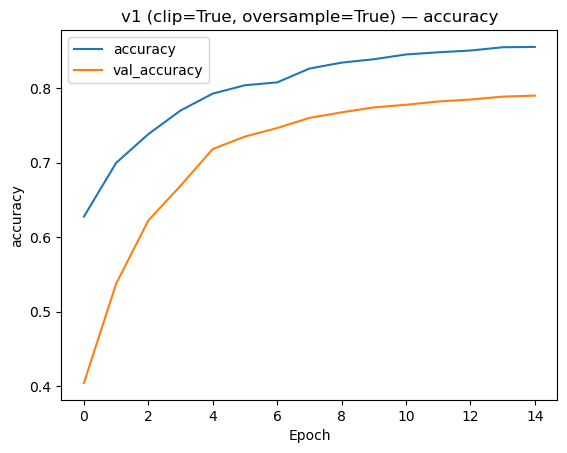

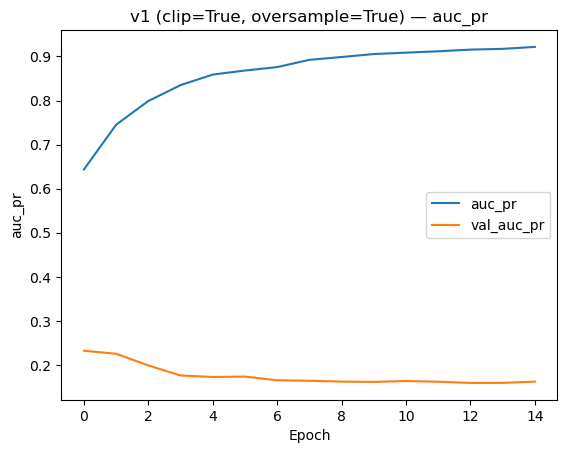

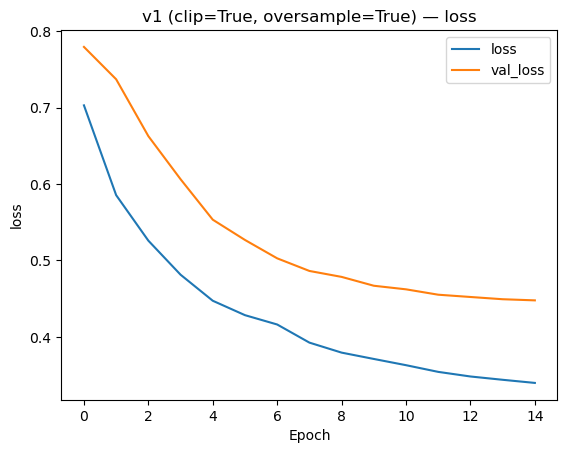

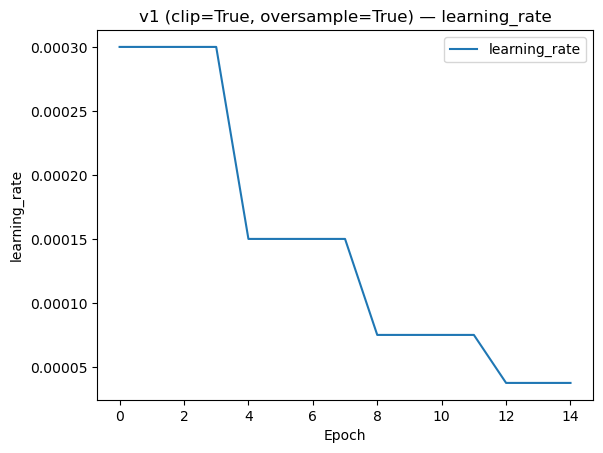

In [24]:
# Latest run for this combo
hist, v, path = load_and_plot_history(clip=True, oversample=True, version=1)

# Or a specific version
#hist, v, path = load_and_plot_history(clip=True, oversample=True, version=3)


Since we specify an adaptive learning rate, I suppose its sufficeint to just specify one learning rate (to save time as well)

Yep we definitely need to monitor AUC-PR.

In [ ]:
# hist = best_estimator.named_steps["model"].history_  # dict with keys like "loss", "val_loss", "accuracy", "val_accuracy"
# best_clf

### V2

Loaded .\manual_mlp_clip=True_oversample=True_v2_history.json (version v2)
Best val_auc_pr = 0.20120 at epoch 4
auc_pr: 0.88555
val_auc_pr: 0.16116
accuracy: 0.82273
val_accuracy: 0.76828
loss: 0.39028
val_loss: 0.45494


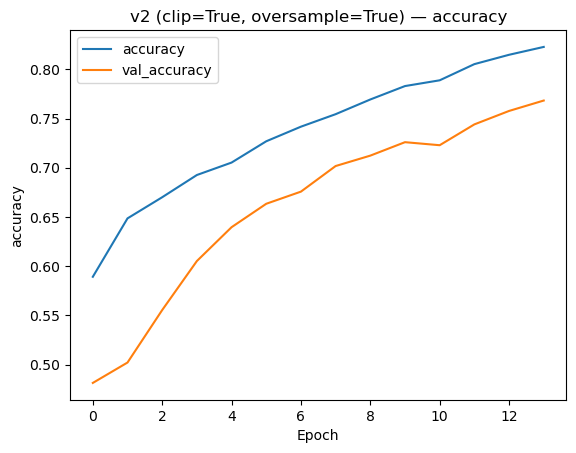

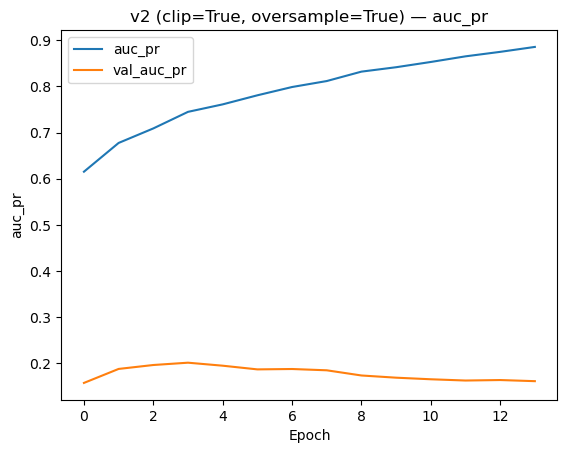

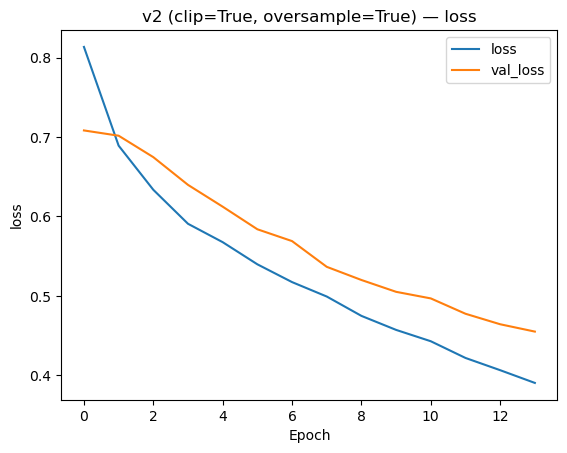

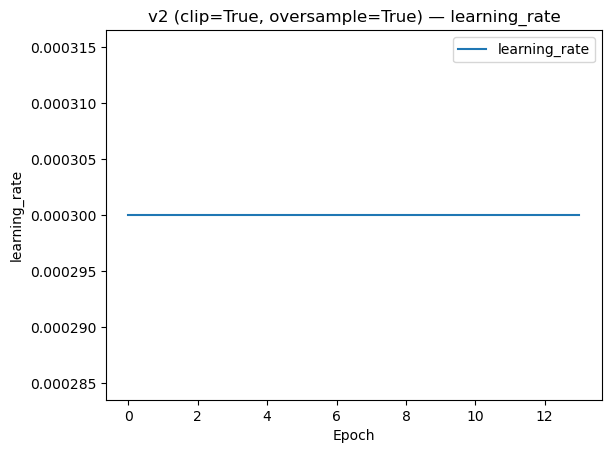

In [25]:
hist2, v2, path2 = load_and_plot_history(clip=True, oversample=True, version=2)

### V3

Loaded .\manual_mlp_clip=True_oversample=True_v3_history.json (version v3)
Best val_auc_pr = 0.20818 at epoch 16
auc_pr: 0.99525
val_auc_pr: 0.18618
accuracy: 0.97154
val_accuracy: 0.90264
loss: 0.09495
val_loss: 0.34917


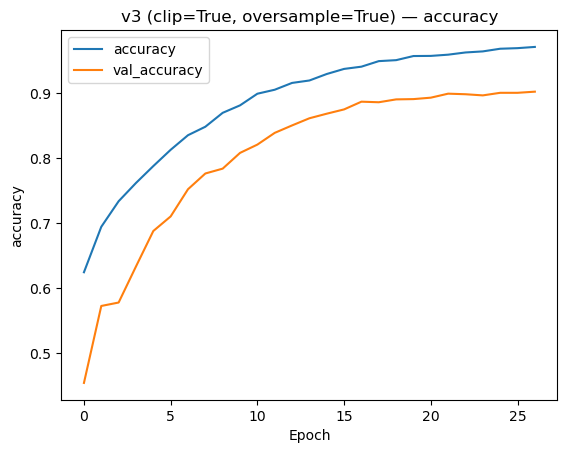

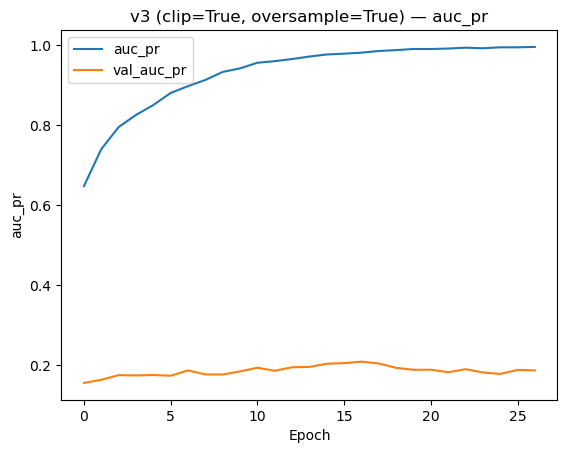

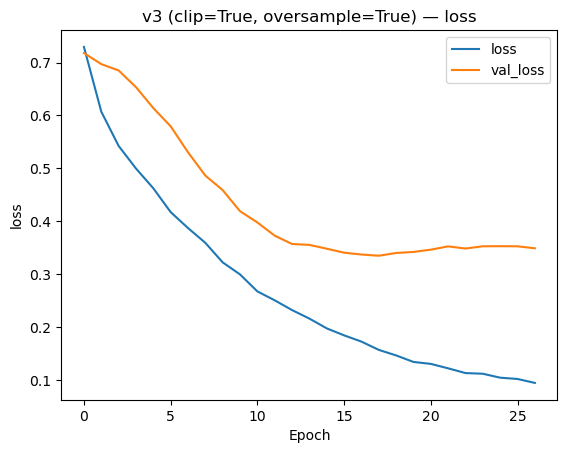

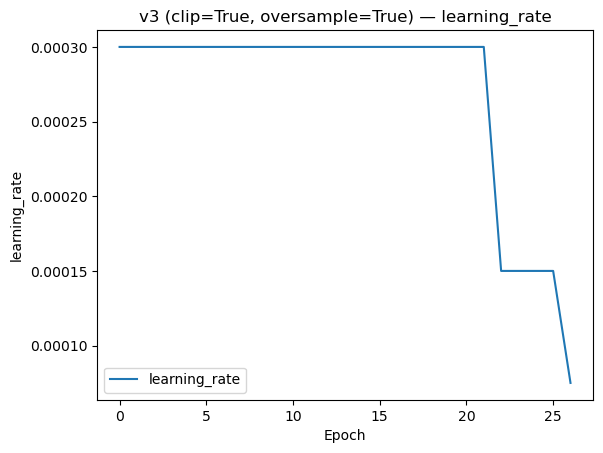

In [21]:
hist3, v3, path3 = load_and_plot_history(clip=True, oversample=True, version=3)

In [ ]:
### TODO: monitor V2 and V3

### V4

Loaded .\manual_mlp_clip=True_oversample=True_v4_history.json (version v4)
Best val_auc_pr = 0.20401 at epoch 19
auc_pr: 0.98872
val_auc_pr: 0.19558
accuracy: 0.95341
val_accuracy: 0.88943
loss: 0.44283
val_loss: 0.67159


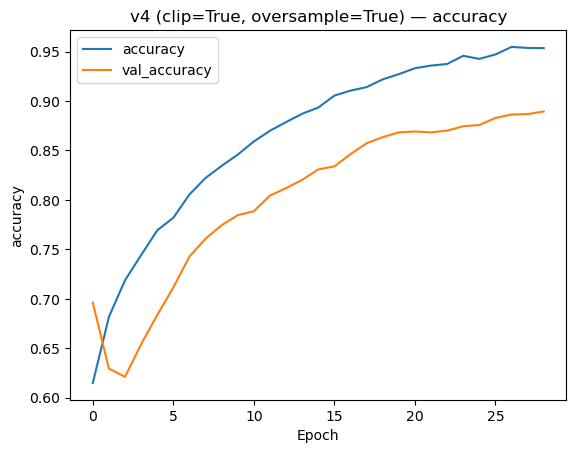

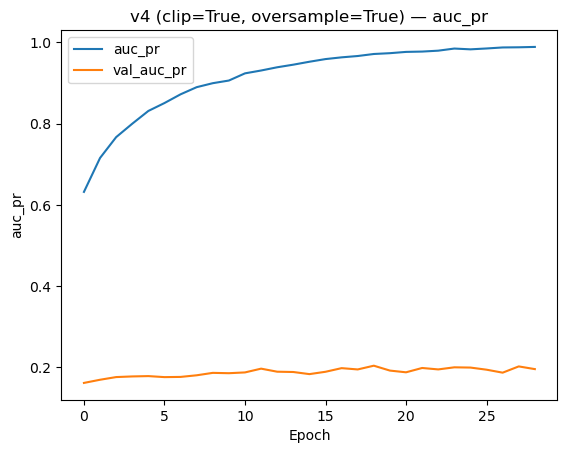

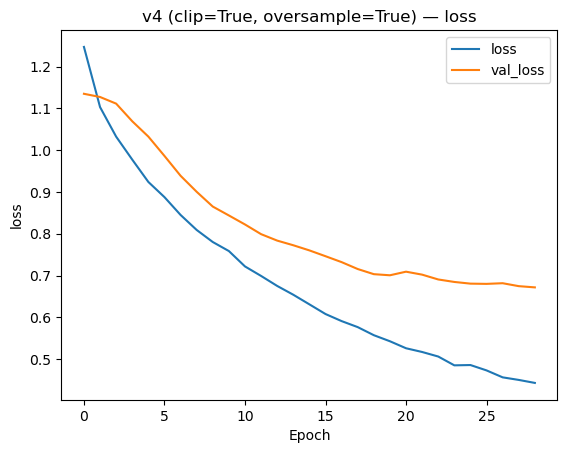

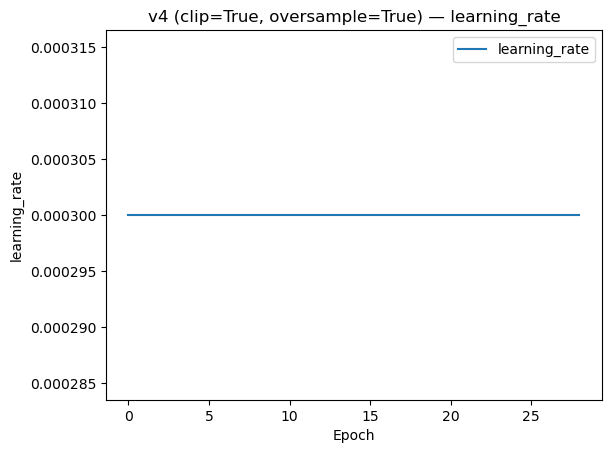

In [28]:
hist4, v4, path4 = load_and_plot_history(clip=True, oversample=True, version=4)

## Focal loss

### V1

Loaded manual_mlp_clip=true_focal=true_v1_history.json (version v1)
Best val_auc_pr = 0.21733 at epoch 46
auc_pr: 0.45218
val_auc_pr: 0.21136
accuracy: 0.94713
val_accuracy: 0.93524
loss: 0.31986
val_loss: 0.35807


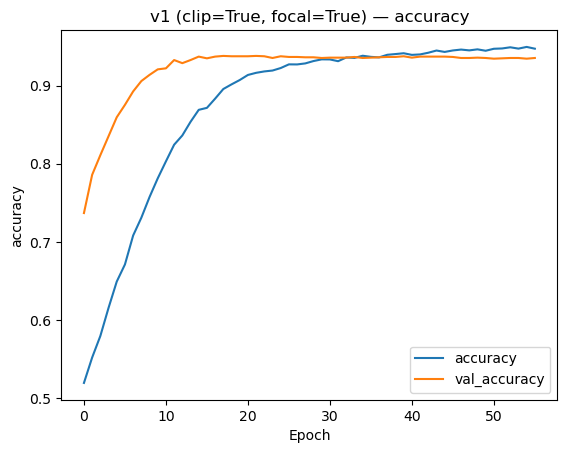

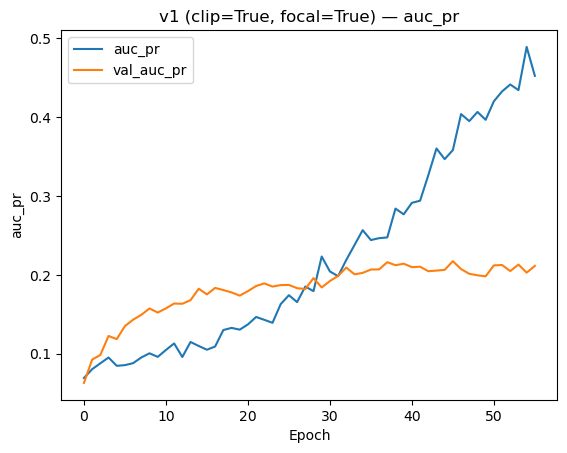

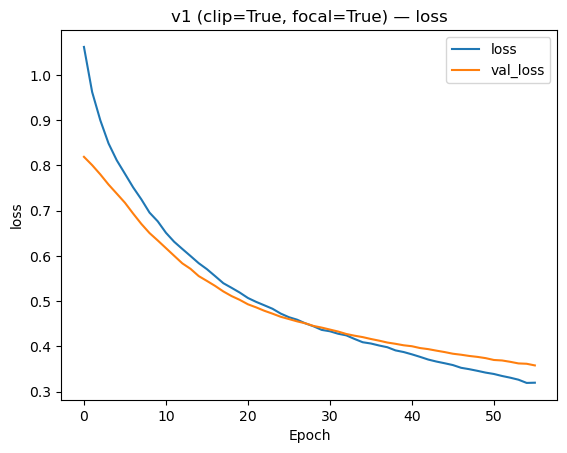

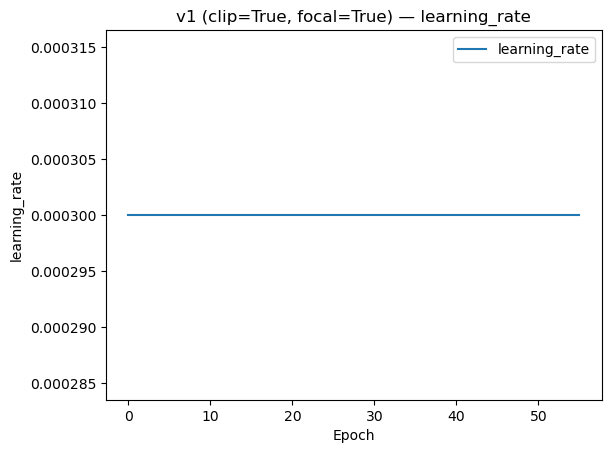

In [103]:
hist_fc1, v_fc1, path_fc1 = load_and_plot_history(clip=True, oversample=False, focal=True, version=1)

### V2

Loaded manual_mlp_clip=true_focal=true_v2_history.json (version v2)
Best val_auc_pr = 0.23968 at epoch 55
auc_pr: 0.21593
val_auc_pr: 0.20324
accuracy: 0.94196
val_accuracy: 0.93480
loss: 0.07763
val_loss: 0.08540


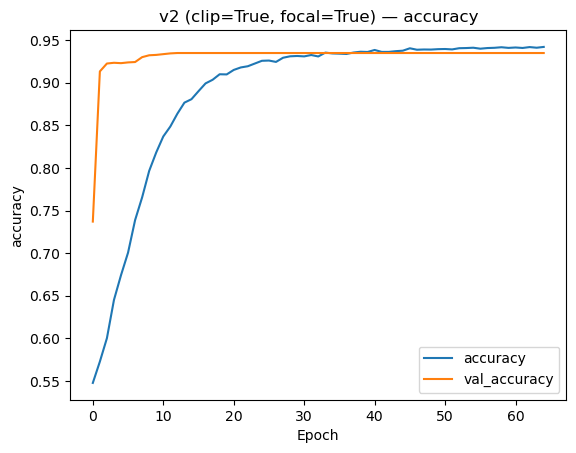

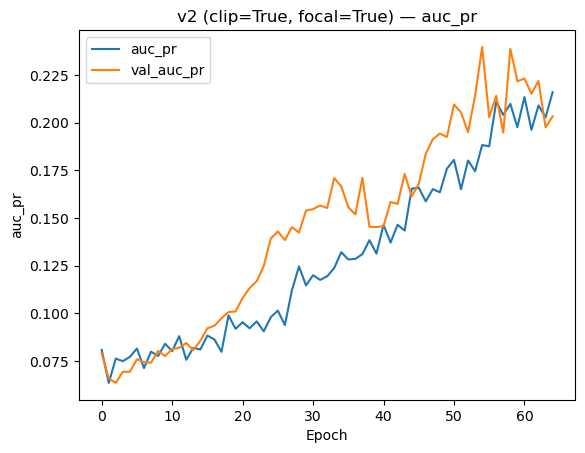

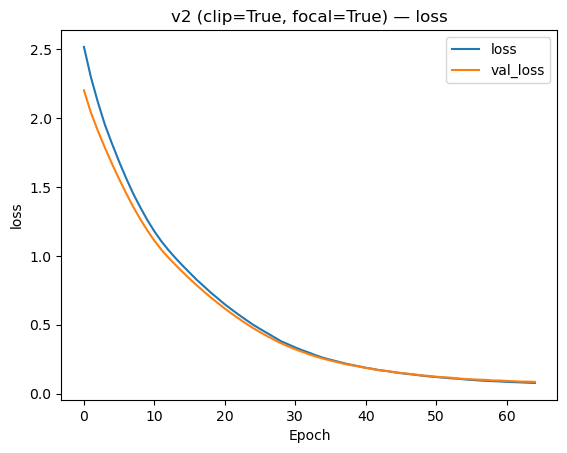

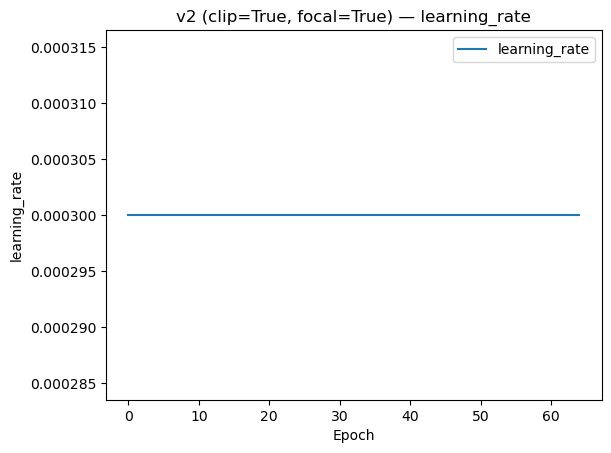

In [116]:
hist_fc2, v_fc2, path_fc2 = load_and_plot_history(clip=True, oversample=False, focal=True, version=2)

# 2.3 HYPERPARAMETER TUNING (CLIPPING & VANILLA)

In [219]:
%%time

manual_grid_vanilla_1 = {
    # build_mlp knobs
    "neurons": [[128,64],[256,128,64]],
    "activation_name": ["relu", "leaky_relu"],
    "bn": [True],
    "dropout": [0.2, 0.3],
    "optimizer": ["adam"],
    "learning_rate": [3e-4],
    # if added weight_decay/reg params to build_mlp, include them here too:
    "weight_decay": [1e-4],
    "reg_type": ["l1_l2", "none"],
    "reg_l1":[1e-6],
    "reg_l2":[1e-6],

    # training loop
    "batch_size": [250, 450],
    "epochs": [500]
    # "callbacks": [[tf.keras.callbacks.EarlyStopping(
    #     monitor="val_loss", mode="min", patience=15, restore_best_weights=True
    # )]]
}



artifacts = hyp_tuning_and_fit_save_only_manual(
    X_all, y_all, train_idx, val_idx,
    numeric_cols, categorical_cols,
    want_IQR_clipping=True, want_oversample=False,
    want_track_val_loss=False,
    grid=manual_grid_vanilla_1, random_state=RANDOM_STATE
)


Next tag is v1.
Iterating over 32 combinations
Comb 1 / 32, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 250, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[1] val PR-AUC=0.1856 (best=0.1856)
Comb 2 / 32, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'l1_l2', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 450, 'epochs': 500}
Val auc pr is tracked during fitting s.t. best weights maximize val auc pr


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[2] val PR-AUC=0.1748 (best=0.1856)
Comb 3 / 32, with 
model_kwargs={'neurons': [128, 64], 'activation_name': 'relu', 'bn': True, 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'none', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 250, 'epochs': 500}


...

[30] val PR-AUC=0.1817 (best=0.1942)
Comb 31 / 32, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'none', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 250, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[31] val PR-AUC=0.1524 (best=0.1942)
Comb 32 / 32, with 
model_kwargs={'neurons': [256, 128, 64], 'activation_name': 'leaky_relu', 'bn': True, 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'reg_type': 'none', 'reg_l1': 1e-06, 'reg_l2': 1e-06}, train_kwargs={'batch_size': 450, 'epochs': 500}


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Val auc pr is tracked during fitting s.t. best weights maximize val auc pr
[32] val PR-AUC=0.1785 (best=0.1942)
✔ Saved: manual_mlp_clip=True_oversample=False_v1_model.keras, manual_mlp_clip=True_oversample=False_v1_history.json, manual_mlp_clip=True_oversample=False_v1_meta.json
CPU times: total: 27min 17s
Wall time: 1h 32min 50s


# 3. EVALUATE GENERALISATION PERFORMANCE 


In [32]:
import json, numpy as np, tensorflow as tf
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score,\
recall_score, confusion_matrix, matthews_corrcoef, balanced_accuracy_score

# --- load meta for V4 to recover hyper-params and best_epoch
with open("manual_mlp_clip=True_oversample=True_v3_meta.json") as f:
    meta = json.load(f)

best_params = meta["best_params"]          # includes neurons, activation, etc.
best_epoch  = max([r["best_epoch"] for r in meta["runs"] if r.get("best_epoch")])  # safe fallback



<Sequential name=sequential, built=True>

## Scrap codes

Retrieve the best model config.

In [90]:
# import json, numpy as np, tensorflow as tf
# from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score,\
# recall_score, confusion_matrix, matthews_corrcoef, balanced_accuracy_score

# # --- load meta for V4 to recover hyper-params and best_epoch
# with open("manual_mlp_clip=True_oversample=True_v3_meta.json") as f:
#     meta = json.load(f)

# best_params = meta["best_params"]          # includes neurons, activation, etc.
# best_epoch  = max([r["best_epoch"] for r in meta["runs"] if r.get("best_epoch")])  # safe fallback

# best_params


# from sklearn.model_selection import train_test_split
# import numpy as np, tensorflow as tf
# from collections import Counter

# # --- 0) Fit preprocessor on (train+val), transform once ---
# pre = make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping=True)
# pre.fit(X_all, y_all)

# X_all_tf = pre.transform(X_all).astype("float32")
# y_all_tf = y_all.to_numpy().astype("int32")

# # --- 1) Tiny calibration split from ORIGINAL distribution (no ROS here) ---
# calib_size = 0.05  # 5% is plenty; can use 0.03–0.10
# X_refit, X_calib, y_refit, y_calib = train_test_split(
#     X_all_tf, y_all_tf,
#     test_size=calib_size,
#     random_state=RANDOM_STATE,
#     stratify=y_all_tf
# )
# print("y_refit:", Counter(y_refit), " | y_calib:", Counter(y_calib))

# # --- 2) Oversample ONLY the refit-train portion ---
# ros = RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=1.0)
# X_refit_os, y_refit_os = ros.fit_resample(X_refit, y_refit)
# X_refit_os = X_refit_os.astype("float32")
# y_refit_os = y_refit_os.astype("int32")
# print("y_refit_os:", Counter(y_refit_os))  # should be balanced

# # --- 3) Build model with fixed hyper-params (from V4 meta) ---
# model_kwargs = {k: v for k, v in best_params.items()
#                 if k not in {"epochs", "batch_size", "callbacks"}}
# meta_info = {"n_features_in_": X_refit_os.shape[1]}
# final_model = build_mlp(meta=meta_info, **model_kwargs)

# # Use best_epoch from dev as a cap; let EarlyStopping stop earlier if needed
# epochs_cap = int(best_epoch)
# batch_size  = int(best_params.get("batch_size", 256))

# # Early stop on validation PR (since that’s the selection metric used)
# cbs = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor="val_auc_pr", mode="max",
#         patience=10, restore_best_weights=True, verbose=1
#     )
# ]

# history_refit = final_model.fit(
#     X_refit_os, y_refit_os,
#     validation_data=(X_calib, y_calib),   # note: NOT oversampled
#     #epochs=epochs_cap,
#     epochs=250,
#     batch_size=batch_size,
#     verbose=1,
#     shuffle=True,
#     callbacks=cbs
# )


# # Transform test once with the refit preprocessor
# DROP_COLS_TEST = [c for c in (ID_COLS + ["y"]) if c in test_df.columns]
# Xte_raw = test_df.drop(columns=DROP_COLS_TEST)
# yte = test_df["y"].to_numpy().astype("int32")

# Xte = pre.transform(Xte_raw).astype("float32")

# # Continuous metrics
# proba_te = final_model.predict(Xte, verbose=0).ravel()
# aucpr_te = average_precision_score(yte, proba_te)
# aucroc_te = roc_auc_score(yte, proba_te)
# print(f"Test AUC-PR = {aucpr_te:.3f} | Test ROC-AUC = {aucroc_te:.3f}")

{'neurons': [512, 256, 128, 32],
 'activation_name': 'leaky_relu',
 'bn': True,
 'dropout': 0.2,
 'optimizer': 'adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'reg_type': 'l1',
 'reg_l1': 1e-06,
 'batch_size': 650,
 'epochs': 400}

In [ ]:
# calibrate using train_df on val_df to find the threshold that, say, maximize F1 score

# then use this threshold to make a binary prediction on the test set

# obtain confusion matrix, precision, recall, MCC, balanced accuracy, F1 score



In [ ]:
# # 3. EVALUATE GENERALISATION PERFORMANCE (feel free to change this)

# final_pipe = grid.best_estimator_
# DROP_COLS_TEST = [c for c in (ID_COLS + ["y"]) if c in test_df.columns]
# Xte = test_df.drop(columns=DROP_COLS_TEST)
# yte = test_df["y"]

# proba_te = final_pipe.predict_proba(Xte)[:, 1]
# print("TEST PR-AUC:", average_precision_score(yte, proba_te))
# print("TEST ROC-AUC:", roc_auc_score(yte, proba_te))

## Threshold tuning

In [284]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

def tune_threshold_from_val(
    model,
    preprocessor,
    X_all, y_all,
    train_idx, val_idx,
    metric="f1",
    n_points=200,
    plot=True,
    model_desc="MLP with focal loss"
):
    """
    Find optimal decision threshold τ using validation fold only.

    Parameters
    ----------
    model : tf.keras.Model
        Fitted model (must output probabilities).
    preprocessor : fitted ColumnTransformer
        Same preprocessor used for train/val/test.
    X_all, y_all : pd.DataFrame / Series
        Combined dataset with positional indices.
    train_idx, val_idx : np.ndarray
        Index arrays identifying train vs val rows.
    metric : str, default="f1"
        Which metric to maximize ("f1", "balanced_f1", or "custom").
    n_points : int
        Number of thresholds to test between 0–1.
    plot : bool
        Whether to show Precision–Recall curves.

    Returns
    -------
    tau_star : float
        Threshold that maximizes the chosen metric.
    metrics_at_best : dict
        Precision, recall, F1, PR-AUC at τ*.
    """
    X_val = X_all.iloc[val_idx]
    y_val = y_all.iloc[val_idx].to_numpy().astype(int)

    Xv = preprocessor.transform(X_val).astype("float32")
    proba = model.predict(Xv, verbose=0).ravel()

    taus = np.linspace(0.01, 0.99, n_points)
    precs, recs, f1s = [], [], []

    for t in taus:
        yhat = (proba > t).astype(int)
        p = precision_score(y_val, yhat, zero_division=0)
        r = recall_score(y_val, yhat, zero_division=0)
        f = f1_score(y_val, yhat, zero_division=0)
        precs.append(p); recs.append(r); f1s.append(f)

    f1s = np.array(f1s)
    best_i = int(f1s.argmax())
    tau_star = float(taus[best_i])

    metrics_at_best = dict(
        tau=tau_star,
        precision=precs[best_i],
        recall=recs[best_i],
        f1=f1s[best_i],
        aucpr=average_precision_score(y_val, proba)
    )

    if plot:
        plt.figure(figsize=(6,4))
        plt.plot(taus, precs, label="Precision")
        plt.plot(taus, recs, label="Recall")
        plt.plot(taus, f1s, label="F1", color="black", lw=2)
        plt.axvline(tau_star, color="red", ls="--", label=f"τ*={tau_star:.3f}")
        plt.xlabel("Threshold τ")
        plt.ylabel("Metric")
        plt.legend()
        plt.title(f"Validation threshold tuning ({metric}-max)\n({model_desc})")
        plt.show()

    print(f"Best τ={tau_star:.3f} with F1={metrics_at_best['f1']:.3f}, "
          f"P={metrics_at_best['precision']:.3f}, R={metrics_at_best['recall']:.3f}")
    return tau_star, metrics_at_best


### Vanilla

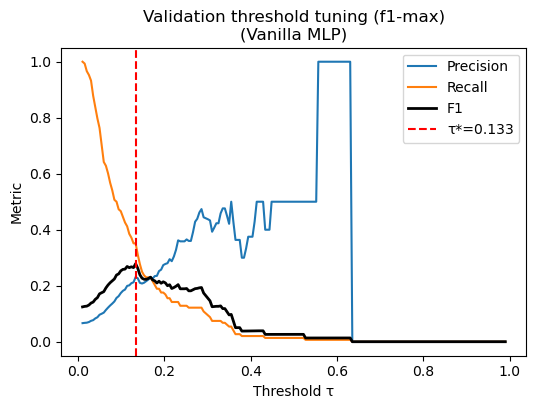

Best τ=0.133 with F1=0.279, P=0.231, R=0.351


In [286]:
mod_vanilla = tf.keras.models.load_model(
    "manual_mlp_clip=True_oversample=False_v1_model.keras",
    compile=False
)

# Fit preprocessor once (same as evaluation step)
pre_vanilla = make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping=True)
pre_vanilla.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])

# Find best τ on val
tau_star_vanilla, metrics_val_vanilla = tune_threshold_from_val(
    model=mod_vanilla,
    preprocessor=pre_vanilla,
    X_all=X_all,
    y_all=y_all,
    train_idx=train_idx,
    val_idx=val_idx,
    model_desc="Vanilla MLP"
)


### Oversampling

### Focal V2

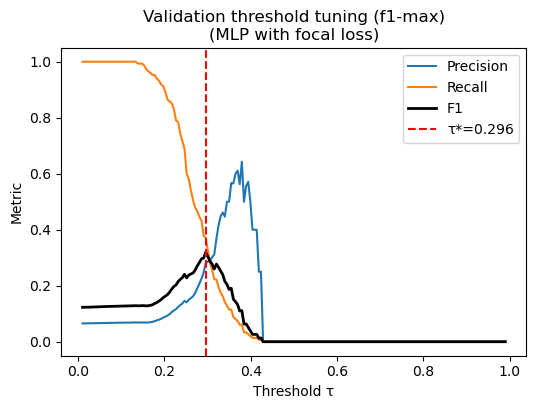

Best τ=0.296 with F1=0.320, P=0.281, R=0.372


In [287]:
mod = tf.keras.models.load_model(
    "manual_mlp_clip=True_focal=True_v2_model.keras",
    compile=False
)

# Fit preprocessor once (same as evaluation step)
pre = make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping=True)
pre.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])

# Find best τ on val
tau_star, metrics_val = tune_threshold_from_val(
    model=mod,
    preprocessor=pre,
    X_all=X_all,
    y_all=y_all,
    train_idx=train_idx,
    val_idx=val_idx
)


## Evaluation function

⚠️NOTE: we need to figure out a way to fix the training process in `refit_and_eval_test_from_Xall` (it is NOT fully deterministic for some reason despite setting `tf.random.set_seed(RANDOM_STATE)` upfront).

In [106]:
import os, re, json, numpy as np, tensorflow as tf
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, matthews_corrcoef, balanced_accuracy_score
)

def _artifact_paths(clip: bool, oversample: bool, focal: bool, version: int | None):
    """Resolve correct artifact file names given training regime and version."""
    if focal and oversample:
        raise ValueError("focal=True is mutually exclusive with oversample=True.")
    base = (
        f"manual_mlp_clip={clip}_focal={focal}_v"
        if focal else f"manual_mlp_clip={clip}_oversample={oversample}_v"
    )
    if version is None:
        cands = [f for f in os.listdir(".") if f.startswith(base) and f.endswith("_meta.json")]
        if not cands:
            raise FileNotFoundError(f"No saved artifacts for prefix: {base}*")
        vers = []
        for f in cands:
            m = re.search(r"_v(\d+)_meta\.json$", f)
            if m: vers.append((int(m.group(1)), f))
        vers.sort()
        version = vers[-1][0]
    meta = f"{base}{version}_meta.json"
    model = f"{base}{version}_model.keras"
    hist  = f"{base}{version}_history.json"
    return model, meta, hist, version


def refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val: float | None,
    clip=True, oversample=True, focal=False,
    version=None, random_state=42
):
    """Refit final MLP on X_all (train+val) and evaluate on test_df."""

    # ---- set seed: lets hope this makes everything reproducible...
    tf.random.set_seed(random_state)

    
    # ---- resolve artifacts and load best params ----
    model_path, meta_path, hist_path, v = _artifact_paths(clip, oversample, focal, version)
    print(f"Using artifacts v{v}: {meta_path}")

    with open(meta_path, "r") as f:
        meta = json.load(f)
    best_params = meta["best_params"]
    best_epoch = int(max(r["best_epoch"] for r in meta["runs"] if r.get("best_epoch")))
    batch_size = int(best_params.get("batch_size", 256))

    # ---- fit preprocessor on X_all (train+val) ----
    pre = make_preprocessor(numeric_cols, categorical_cols, want_IQR_clipping=clip)
    pre.fit(X_all, y_all)
    X_all_tf = pre.transform(X_all).astype("float32")
    y_all_tf = y_all.to_numpy().astype("int32")

    # ---- oversample or not ----
    if focal:
        print("Focal loss regime detected — skipping oversampling.")
        X_refit, y_refit = X_all_tf, y_all_tf
    elif oversample:
        from imblearn.over_sampling import RandomOverSampler
        ros = RandomOverSampler(random_state=random_state, sampling_strategy=1.0)
        X_refit, y_refit = ros.fit_resample(X_all_tf, y_all_tf)
        print("Oversampled class distribution:", np.bincount(y_refit))
    else:
        X_refit, y_refit = X_all_tf, y_all_tf

    # ---- rebuild and refit model ----
    TRAIN_KEYS = {"epochs", "batch_size", "callbacks"}
    model_kwargs = {k: v for k, v in best_params.items() if k not in TRAIN_KEYS}

    meta_info = {"n_features_in_": X_refit.shape[1]}
    final_model = build_mlp(meta=meta_info, **model_kwargs)

    history = final_model.fit(
        X_refit, y_refit,
        epochs=best_epoch,
        batch_size=batch_size,
        verbose=1,
        shuffle=True
    )

    # ---- transform test ----
    ID_COLS = ["subject_id", "hadm_id", "stay_id", "is_mi", "is_pcr", "is_cbs"]
    DROP_COLS_TEST = [c for c in (ID_COLS + ["y"]) if c in test_df.columns]
    Xte_raw = test_df.drop(columns=DROP_COLS_TEST)
    yte = test_df["y"].to_numpy().astype("int32")
    Xte = pre.transform(Xte_raw).astype("float32")

    # ---- continuous metrics ----
    proba_te = final_model.predict(Xte, verbose=0).ravel()
    aucpr_te = average_precision_score(yte, proba_te)
    aucroc_te = roc_auc_score(yte, proba_te)
    print(f"Test AUC-PR = {aucpr_te:.3f} | Test ROC-AUC = {aucroc_te:.3f}")

    # ---- thresholded metrics (if τ provided) ----
    out = {
        "aucpr_test": float(aucpr_te),
        "aucroc_test": float(aucroc_te),
        "history": history.history
    }

    if tau_from_val is not None:
        tau = float(tau_from_val)
        yhat_te = (proba_te > tau).astype(int)
        out.update({
            "tau_used": tau,
            "precision": float(precision_score(yte, yhat_te, zero_division=0)),
            "recall": float(recall_score(yte, yhat_te, zero_division=0)),
            "f1": float(f1_score(yte, yhat_te, zero_division=0)),
            "mcc": float(matthews_corrcoef(yte, yhat_te)),
            "balanced_accuracy": float(balanced_accuracy_score(yte, yhat_te)),
            "confusion_matrix": confusion_matrix(yte, yhat_te).tolist()
        })
        print(f"τ (from val) = {tau:.3f}")
        print(f"Precision={out['precision']:.3f} Recall={out['recall']:.3f} "
              f"F1={out['f1']:.3f} MCC={out['mcc']:.3f} "
              f"BalancedAcc={out['balanced_accuracy']:.3f}")
        print("Confusion matrix:\n", out["confusion_matrix"])

    return out, final_model, pre


## Vanilla

### V1

In [220]:
results_vanilla, model_vanilla, preproc_vanilla = refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val=0.29,
    clip=True, oversample=False, focal=False,
    version=1
)


Using artifacts v1: manual_mlp_clip=True_oversample=False_v1_meta.json


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5200 - auc_pr: 0.0747 - loss: 0.8858
Epoch 2/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5587 - auc_pr: 0.0868 - loss: 0.7970
Epoch 3/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5981 - auc_pr: 0.0826 - loss: 0.7349
Epoch 4/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6284 - auc_pr: 0.0840 - loss: 0.6892
Epoch 5/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6557 - auc_pr: 0.0841 - loss: 0.6569
Epoch 6/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6821 - auc_pr: 0.0795 - loss: 0.6241
Epoch 7/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7151 - auc_pr: 0.0781 - loss: 0.5878
Epoch 8/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7465 - auc_pr: 0.0852 - loss: 0.5581
Epoch 9/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7713 - auc_pr: 0.0862 - loss: 0.5308
Epoch 10/131
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7981 -

## Focal 

### V1

In [107]:
results_focal, model_focal, preproc_focal = refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val=0.22,
    clip=True, oversample=False, focal=True,
    version=1
)


Using artifacts v1: manual_mlp_clip=True_focal=True_v1_meta.json
Focal loss regime detected — skipping oversampling.


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5285 - auc_pr: 0.0673 - loss: 1.0818
Epoch 2/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5576 - auc_pr: 0.0723 - loss: 0.9530
Epoch 3/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5970 - auc_pr: 0.0772 - loss: 0.8805
Epoch 4/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6364 - auc_pr: 0.0755 - loss: 0.8283
Epoch 5/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6722 - auc_pr: 0.0839 - loss: 0.7866
Epoch 6/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7143 - auc_pr: 0.0855 - loss: 0.7496
Epoch 7/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7397 - auc_pr: 0.0853 - loss: 0.7232
Epoch 8/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7671 - auc_pr: 0.0964 - loss: 0.6914
Epoch 9/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7938 - auc_pr: 0.0946 - loss: 0.6678
Epoch 10/56
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8144 - auc_pr: 0

### V2 (BEST: Test AUC-PR = 0.194 | Test ROC-AUC = 0.742)

In [110]:
results_focal2, model_focal2, preproc_focal2 = refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val=0.22,
    clip=True, oversample=False, focal=True,
    version=2
)


Using artifacts v2: manual_mlp_clip=True_focal=True_v2_meta.json
Focal loss regime detected — skipping oversampling.
Epoch 1/63


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5290 - auc_pr: 0.0619 - loss: 2.5018
Epoch 2/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5649 - auc_pr: 0.0652 - loss: 2.2375
Epoch 3/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6088 - auc_pr: 0.0684 - loss: 2.0303
Epoch 4/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6553 - auc_pr: 0.0740 - loss: 1.8462
Epoch 5/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6923 - auc_pr: 0.0698 - loss: 1.6881
Epoch 6/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7312 - auc_pr: 0.0694 - loss: 1.5395
Epoch 7/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7724 - auc_pr: 0.0766 - loss: 1.4026
Epoch 8/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8043 - auc_pr: 0.0799 - loss: 1.2808
Epoch 9/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8236 - auc_pr: 0.0803 - loss: 1.1784
Epoch 10/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8464 - auc_pr: 0.0882 - loss

### V2 (BEST: use tuned evals from here)

In [118]:
test_df

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,MI
14,13678189,20731516,33368602,0,1,0,0,61,M,WHITE,...,105.0,147.0,3.4,294.0,10.2,5.1,1.5,1.03,0,MI
26,15156174,27579747,33046466,0,1,0,0,51,M,WHITE,...,10.0,142.0,4.3,107.0,11.7,6.4,NaN,1.14,1,MI
37,17031608,23375584,39314937,0,1,0,0,82,F,WHITE,...,19.0,143.0,4.2,113.0,10.3,7.1,NaN,0.48,0,MI
40,17579498,21787496,30038282,0,1,0,0,82,M,WHITE,...,18.0,137.0,3.8,110.0,11.3,8.7,NaN,1.49,0,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15414,19960105,27042506,38591947,0,0,0,1,65,F,WHITE,...,22.0,137.0,3.8,90.0,7.8,6.3,NaN,NaN,1,CABG
15415,19960105,27042506,36134835,0,0,0,1,65,F,WHITE,...,60.0,143.0,5.3,127.0,10.9,9.9,NaN,NaN,2,CABG
15416,19963068,20111271,34132866,0,0,0,1,69,M,AMERICAN INDIAN/ALASKA NATIVE,...,60.0,139.0,5.9,74.0,12.3,9.7,1.1,NaN,0,CABG
15420,19966568,25640873,32059064,0,0,0,1,42,M,WHITE,...,9.0,134.0,4.3,87.0,13.4,11.2,4.4,NaN,0,CABG


In [114]:
results_focal2_1, model_focal2_1, preproc_focal2_1 = refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val=tau_star,
    clip=True, oversample=False, focal=True,
    version=2
)


Using artifacts v2: manual_mlp_clip=True_focal=True_v2_meta.json
Focal loss regime detected — skipping oversampling.
Epoch 1/63


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4953 - auc_pr: 0.0582 - loss: 2.4614
Epoch 2/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5439 - auc_pr: 0.0637 - loss: 2.2083
Epoch 3/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5979 - auc_pr: 0.0686 - loss: 2.0035
Epoch 4/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6482 - auc_pr: 0.0760 - loss: 1.8186
Epoch 5/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6940 - auc_pr: 0.0655 - loss: 1.6529
Epoch 6/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7347 - auc_pr: 0.0766 - loss: 1.5022
Epoch 7/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7727 - auc_pr: 0.0739 - loss: 1.3664
Epoch 8/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8076 - auc_pr: 0.0789 - loss: 1.2421
Epoch 9/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8240 - auc_pr: 0.0767 - loss: 1.1370
Epoch 10/63
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8449 - auc_pr: 0.0810 - loss: 

## Oversample

#### V4 (Test AUC-PR = 0.144 | Test ROC-AUC = 0.692)

In [108]:
results_os, model_os, preproc_os = refit_and_eval_test_from_Xall(
    X_all, y_all, test_df,
    numeric_cols, categorical_cols,
    tau_from_val=0.27,
    clip=True, oversample=True, focal=False,
    version=4
)


Using artifacts v4: manual_mlp_clip=True_oversample=True_v4_meta.json
Oversampled class distribution: [12135 12135]
Epoch 1/49


D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\OneDrive\Documents\anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6204 - auc_pr: 0.6406 - loss: 1.2229
Epoch 2/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6826 - auc_pr: 0.7246 - loss: 1.0885
Epoch 3/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7199 - auc_pr: 0.7741 - loss: 1.0149
Epoch 4/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7410 - auc_pr: 0.8055 - loss: 0.9638
Epoch 5/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7635 - auc_pr: 0.8270 - loss: 0.9192
Epoch 6/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7871 - auc_pr: 0.8501 - loss: 0.8759
Epoch 7/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8012 - auc_pr: 0.8669 - loss: 0.8395
Epoch 8/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8151 - auc_pr: 0.8799 - loss: 0.8084
Epoch 9/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8269 - auc_pr: 0.8943 - loss: 0.7763
Epoch 10/49
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8398 - auc_pr: 0.9085 - los

## TODO: group level eval

In [125]:
import numpy as np, pandas as pd
from sklearn import metrics as skm

# --- collapsed race categories (kept consistent with split logic) ---
def collapse_race(r):
    if pd.isna(r): return "UNKNOWN/OTHER"
    r = str(r).upper()
    if r.startswith("WHITE"): return "WHITE"
    if r.startswith("BLACK"): return "BLACK"
    if r.startswith("ASIAN"): return "ASIAN"
    if "HISPANIC" in r or "SOUTH AMERICAN" in r: return "HISPANIC"
    if "PORTUGUESE" in r: return "PORTUGUESE"
    if "PACIFIC ISLANDER" in r: return "PACIFIC"
    fallback = {"OTHER","UNKNOWN","UNABLE TO OBTAIN","PATIENT DECLINED TO ANSWER",
                "MULTIPLE RACE/ETHNICITY","AMERICAN INDIAN/ALASKA NATIVE",
                "WHITE - OTHER EUROPEAN","WHITE - EASTERN EUROPEAN","WHITE - RUSSIAN",
                "WHITE - BRAZILIAN","BLACK/CAPE VERDEAN","BLACK/CARIBBEAN ISLAND"}
    return "UNKNOWN/OTHER" if r in fallback else "UNKNOWN/OTHER"

# --- small helpers ---
def _safe_auc(y, s, fn):
    # return NaN if a group has only one class
    ys = np.asarray(y)
    if ys.min() == ys.max(): 
        return np.nan
    return fn(ys, np.asarray(s))

def _cm_metrics(y, yhat):
    tn, fp, fn, tp = skm.confusion_matrix(y, yhat, labels=[0,1]).ravel()
    prec = skm.precision_score(y, yhat, zero_division=0)
    rec  = skm.recall_score(y, yhat, zero_division=0)
    f1   = skm.f1_score(y, yhat, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    bal_acc = (rec + spec) / 2 if not np.isnan(spec) else np.nan
    mcc = skm.matthews_corrcoef(y, yhat) if len(np.unique(y)) == 2 else np.nan
    return dict(TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp),
                Precision=prec, Recall=rec, F1=f1, Specificity=spec,
                BalancedAccuracy=bal_acc, MCC=mcc,
                Accuracy=skm.accuracy_score(y, yhat))

def _bin_age(age, bins=(0,50,60,70,80,150),
             labels=("0-49","50–59","60–69","70–79","80+")):
    return pd.cut(pd.to_numeric(age), bins=bins, labels=labels, right=False)

# --- core grouper ---
def group_eval_table(df, y_col, score_col, group_col, tau):
    """
    df must contain: y_col (0/1), score_col (probability), group_col (category)
    Returns one DataFrame of metrics per group.
    """
    rows = []
    for g in sorted(df[group_col].dropna().unique(), key=lambda x: str(x)):
        sub = df[df[group_col] == g]
        y   = sub[y_col].astype(int).to_numpy()
        s   = sub[score_col].to_numpy()
        yhat = (s >= tau).astype(int)

        row = dict(
            Group=str(g),
            N=len(sub),
            Positives=int(y.sum()),
            Prevalence=(y.mean())
        )
        row.update(_cm_metrics(y, yhat))
        # within-group continuous metrics (NaN if only one class)
        row["AUC-PR"]  = _safe_auc(y, s, skm.average_precision_score)
        row["ROC-AUC"] = _safe_auc(y, s, skm.roc_auc_score)
        rows.append(row)

    out = pd.DataFrame(rows)
    # deltas vs overall for quick fairness reads
    overall = df[[y_col, score_col]].copy()
    overall_pred = (overall[score_col] >= tau).astype(int)
    overall_rec = skm.recall_score(overall[y_col], overall_pred, zero_division=0)
    overall_ppv = skm.precision_score(overall[y_col], overall_pred, zero_division=0)
    out["Delta_Recall"]    = out["Recall"] - overall_rec
    out["Delta_Precision"] = out["Precision"] - overall_ppv
    return out.sort_values("Group").reset_index(drop=True)

# --- public API ---
def evaluate_groups_on_test(test_df, y_proba, tau,
                            y_col="y",
                            cohort_col="cohort",
                            race_col="race",
                            age_col="age",
                            age_bins=(0,50,60,70,80,150),
                            age_labels=("0-49","50–59","60–69","70–79","80+")):
    """
    Returns: dict with three tables: by_cohort, by_age_bin, by_race_merged
    """
    df = test_df.copy()
    df["_y_"] = test_df[y_col].astype(int).to_numpy()
    df["_p_"] = np.asarray(y_proba).ravel()
    # build grouping columns
    df["_age_bin_"]   = _bin_age(df[age_col], age_bins, age_labels)
    df["_race_merged_"] = df[race_col].map(collapse_race)

    by_cohort   = group_eval_table(df, "_y_", "_p_", cohort_col, tau)
    by_age      = group_eval_table(df, "_y_", "_p_", "_age_bin_", tau)
    by_race     = group_eval_table(df, "_y_", "_p_", "_race_merged_", tau)

    return {"by_cohort": by_cohort, "by_age_bin": by_age, "by_race_merged": by_race}


### Focal V2

In [292]:
# we  have: results_focal2_1, model_focal2_1, preproc_focal2_1, test_df, tau_star

# quickly predict predicted probs for test
DROP_COLS_TEST = [c for c in (["subject_id","hadm_id","stay_id","is_mi","is_pcr","is_cbs","y"]) if c in test_df.columns]
Xte_raw = test_df.drop(columns=DROP_COLS_TEST)
Xte_tf  = preproc_focal2_1.transform(Xte_raw).astype("float32")
y_proba_test = model_focal2_1.predict(Xte_tf, verbose=0).ravel()

tables = evaluate_groups_on_test(
    test_df=test_df,
    y_proba=y_proba_test,
    tau=tau_star,                # F1-optimal thershold from val
    y_col="y",
    cohort_col="cohort",
    race_col="race",
    age_col="age"
)

# Access:
by_cohort   = tables["by_cohort"]
by_age_bin  = tables["by_age_bin"]
by_race     = tables["by_race_merged"]

sort_col = "F1"

cols_to_display = ['Group', 'N', 'Positives', 'Prevalence', 'Precision', 'Recall', 'F1', 'BalancedAccuracy', 'MCC', 'TN', 'FP', 'FN', 'TP']


print('-'*50, "Evaluation by Cohort", '-'*50)
display(by_cohort[cols_to_display].sort_values(sort_col, ascending=False))
print('-'*50, "Evaluation by (Binned) Age", '-'*50)
display(by_age_bin[cols_to_display].sort_values(sort_col, ascending=False))
print('-'*50, "Evaluation by (Collapsed) Race", '-'*50)
display(by_race[cols_to_display].sort_values(sort_col, ascending=False))




-------------------------------------------------- Evaluation by Cohort --------------------------------------------------


,Group,N,Positives,Prevalence,Precision,Recall,F1,BalancedAccuracy,MCC,TN,FP,FN,TP
0,CABG,1138,51,0.044815,0.190476,0.392157,0.256410,0.656980,0.224455,1002,85,31,20
1,MI,779,58,0.074454,0.119205,0.620690,0.200000,0.625879,0.135644,455,266,22,36
2,PCI,336,13,0.038690,0.100917,0.846154,0.180328,0.771374,0.223586,225,98,2,11


-------------------------------------------------- Evaluation by (Binned) Age --------------------------------------------------


,Group,N,Positives,Prevalence,Precision,Recall,F1,BalancedAccuracy,MCC,TN,FP,FN,TP
2,60–69,668,40,0.059880,0.176991,0.500000,0.261438,0.675955,0.222719,535,93,20,20
3,70–79,646,29,0.044892,0.126761,0.620690,0.210526,0.709859,0.209864,493,124,11,18
1,50–59,356,19,0.053371,0.121622,0.473684,0.193548,0.640403,0.155546,272,65,10,9
0,0-49,148,6,0.040541,0.111111,0.500000,0.181818,0.665493,0.169026,118,24,3,3
4,80+,435,28,0.064368,0.106250,0.607143,0.180851,0.627896,0.130178,264,143,11,17


-------------------------------------------------- Evaluation by (Collapsed) Race --------------------------------------------------


,Group,N,Positives,Prevalence,Precision,Recall,F1,BalancedAccuracy,MCC,TN,FP,FN,TP
1,BLACK,121,8,0.066116,0.296296,1.000000,0.457143,0.915929,0.496464,94,19,0,8
6,WHITE,1564,84,0.053708,0.126984,0.571429,0.207792,0.674228,0.183497,1150,330,36,48
0,ASIAN,49,4,0.081633,0.142857,0.250000,0.181818,0.558333,0.091287,39,6,3,1
5,UNKNOWN/OTHER,448,24,0.053571,0.114943,0.416667,0.180180,0.617531,0.133801,347,77,14,10
2,HISPANIC,62,2,0.032258,0.000000,0.000000,0.000000,0.366667,-0.107676,44,16,2,0
3,PACIFIC,4,0,0.000000,0.000000,0.000000,0.000000,0.500000,NaN,4,0,0,0
4,PORTUGUESE,5,0,0.000000,0.000000,0.000000,0.000000,0.400000,NaN,4,1,0,0


In [295]:
val_df.y.value_counts(normalize=True)

y
0    0.934802
1    0.065198
Name: proportion, dtype: float64

In [289]:
tables["by_cohort"].columns

Index(['Group', 'N', 'Positives', 'Prevalence', 'TN', 'FP', 'FN', 'TP',
       'Precision', 'Recall', 'F1', 'Specificity', 'BalancedAccuracy', 'MCC',
       'Accuracy', 'AUC-PR', 'ROC-AUC', 'ΔRecall', 'ΔPrecision'],
      dtype='object')

In [131]:
# sanity check: ensure my implementation of group level evalluation is sound
sum(by_age_bin.FP) == sum(by_cohort.FP) == sum(by_race.FP)

True

Older patients (>70), white patients and MI patients hard to predict

## TODO: SHAP feature importance

### Functions

In [202]:
# ---- SHAP wrapper for MLP + ColumnTransformer ---------------------------------
import numpy as np, pandas as pd, shap, tensorflow as tf

def _ohe_feature_names(pre: "ColumnTransformer",
                       numeric_cols, categorical_cols) -> list[str]:
    """Recover post-transform feature names in the exact column order."""
    names = []
    # numeric block: passthrough names 1:1 (AFTER scaling)
    names.extend(list(numeric_cols))

    # categorical block: OHE feature names (with original col prefix)
    ohe = pre.named_transformers_["cat"].named_steps["ohe"]
    cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
    names.extend(cat_names)
    return names

def _group_index_map(feature_names: list[str],
                     numeric_cols, categorical_cols) -> dict[str, np.ndarray]:
    """Map each original feature (num) or categorical column (all its OHEs) to indices."""
    idx_map = {}

    # numeric: 1 index each
    f2i = {f:i for i,f in enumerate(feature_names)}
    for c in numeric_cols:
        idx_map[c] = np.array([f2i[c]], dtype=int)

    # categorical: group by OHE prefix "colname_"
    # note: SHAP names like "race_ASIAN", so group by "race_"
    for c in categorical_cols:
        prefix = f"{c}_"
        idx = np.array([i for i,f in enumerate(feature_names) if f.startswith(prefix)], dtype=int)
        if len(idx) == 0:
            # handle degenerate cases (constant col got dropped): skip gracefully
            continue
        idx_map[c] = idx

    return idx_map

class MyLayer(tf.keras.layers.Layer):
    def call(self, out):
        out = tf.clip_by_value(out, 1e-6, 1 - 1e-6)
        logit = tf.math.log(out / (1.0 - out))
        return logit


def _model_with_logit_output(model: tf.keras.Model) -> tf.keras.Model:
    """Return a wrapper model that outputs log-odds even if the base model has no .input graph."""
    import tensorflow as tf
    import numpy as np

    # Try the symbolic graph path first
    try:
        inp = model.input
        out = model.output
    except Exception:
        # Fall back: build symbolic input manually using known input shape
        # Assumes model expects flat numeric vector input: (None, n_features)
        if hasattr(model, "layers") and hasattr(model.layers[0], "input_shape"):
            in_shape = model.layers[0].input_shape
        elif hasattr(model, "input_shape"):
            in_shape = model.input_shape
        else:
            raise ValueError("Cannot infer input shape; please pass one sample first.")

        # If tuple like (None, n_features), extract n_features
        if isinstance(in_shape, (tuple, list)):
            if isinstance(in_shape[0], (tuple, list)):
                in_shape = in_shape[0]
        if in_shape[0] is None:
            in_shape = (1,) + tuple(in_shape[1:])
        # make a symbolic Input tensor
        inp = tf.keras.Input(shape=in_shape[1:], dtype=tf.float32)
        out = model(inp, training=False)

    # Compute log-odds output
    # out = tf.clip_by_value(out, 1e-6, 1 - 1e-6)
    # logit = tf.math.log(out / (1.0 - out))
    logit = MyLayer()(out)
    wrapped = tf.keras.Model(inputs=inp, outputs=logit)
    return wrapped


def explain_mlp_with_shap(
    model: tf.keras.Model,
    preprocessor,                   # fitted ColumnTransformer
    X_raw: "pd.DataFrame|np.ndarray",
    numeric_cols, categorical_cols,
    *,
    background_size: int = 512,     # for SHAP masker
    eval_size: int | None = None,   # subsample to speed up; None = all
    use_logit_link: bool = True,    # recommended for binary classifiers
    random_state: int = 42,
):
    """
    Returns:
      shap_values: np.ndarray [n_eval, n_features_post_transform]
      per_feature: pd.DataFrame with |feature| mean(|SHAP|) for every transformed column
      grouped:     pd.DataFrame with mean(|SHAP|) aggregated back to original columns
      meta:        dict with keys {feature_names, group_index_map, X_eval, X_bg}
    """
    rng = np.random.default_rng(random_state)

    # 1) Transform X, pick background/eval sets
    X_t = preprocessor.transform(X_raw).astype("float32")
    n = X_t.shape[0]
    if eval_size is None or eval_size >= n:
        eval_idx = np.arange(n)
    else:
        eval_idx = rng.choice(n, size=eval_size, replace=False)

    bg_idx = rng.choice(n, size=min(background_size, n), replace=False)
    X_eval = X_t[eval_idx]
    X_bg   = X_t[bg_idx]

    # 2) Build explainer (Deep/Gradient if possible, else Kernel auto-fallback)
    f_names = _ohe_feature_names(preprocessor, numeric_cols, categorical_cols)
    wrapped = _model_with_logit_output(model) if use_logit_link else model
    masker  = shap.maskers.Independent(X_bg)

    explainer = shap.Explainer(wrapped, masker=masker)  # algorithm="auto"
    sv = explainer(X_eval, max_evals=2_000)             # returns shap._explanation.Explanation
    shap_values = np.asarray(sv.values)                 # [n_eval, n_features]

    # 3) Per-transformed-feature importance
    per_feature = (pd.DataFrame({
        "feature": f_names,
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True))

    # 4) Group back to original columns
    idx_map = _group_index_map(f_names, numeric_cols, categorical_cols)
    rows = []
    for g, idx in idx_map.items():
        if len(idx) == 0: 
            continue
        g_mean = np.mean(np.abs(shap_values[:, idx]), axis=None)  # mean over samples & indices
        rows.append({"group": g, "mean_abs_shap": float(g_mean), "n_transformed": int(len(idx))})
    grouped = (pd.DataFrame(rows)
               .sort_values("mean_abs_shap", ascending=False)
               .reset_index(drop=True))

    # meta = {
    #     "feature_names": f_names,
    #     "group_index_map": idx_map,
    #     "X_eval": X_eval,
    #     "X_background": X_bg,
    #     "use_logit_link": use_logit_link,
    # }

    meta = {
        "feature_names": f_names,
        "group_index_map": idx_map,
        "X_eval": X_eval,
        "X_background": X_bg,
        "eval_indices": eval_idx,
        "use_logit_link": use_logit_link
    }

    return shap_values, per_feature, grouped, meta


### Oversampling

In [269]:
sv_os, per_feat_os, grouped_os, meta_os = explain_mlp_with_shap(
    model_os, preproc_os,
    test_df,
    numeric_cols, categorical_cols,
    background_size=512,
    eval_size=200,
    use_logit_link=True,
    random_state=RANDOM_STATE
)


display(grouped_os.head(15))      # top groups (age, OASIS, cohort, etc.)
display(per_feat_os.head(25))     # top one-hot levels and numeric features




Text(0.5, 1.0, 'SHAP for oversampled MLP')

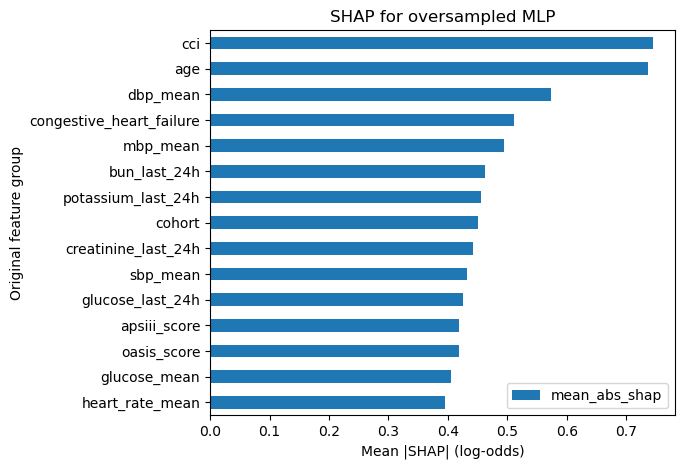

In [280]:
# Optional: quick plot for grouped importances
ax = grouped_os.head(15).iloc[::-1].plot(kind="barh", x="group", y="mean_abs_shap", figsize=(6,5))
ax.set_xlabel("Mean |SHAP| (log-odds)"); ax.set_ylabel("Original feature group");
ax.set_title("SHAP for oversampled MLP")

### Focal V2

PermutationExplainer explainer: 201it [05:20,  1.65s/it]                                                                          


,group,mean_abs_shap,n_transformed
0,dbp_mean,0.153504,1
1,cci,0.132455,1
2,spo2_mean,0.114981,1
3,apsiii_score,0.105790,1
4,mbp_mean,0.091354,1
5,bun_last_24h,0.083870,1
6,congestive_heart_failure,0.082285,1
7,first_day_sofa,0.062439,1
8,diabetes_without_cc,0.061794,1
9,lactate_last_24h,0.060564,1


,feature,mean_abs_shap
0,dbp_mean,0.153504
1,cci,0.132455
2,spo2_mean,0.114981
3,apsiii_score,0.105790
4,mbp_mean,0.091354
5,bun_last_24h,0.083870
6,congestive_heart_failure,0.082285
7,cohort_CABG,0.067600
8,first_day_sofa,0.062439
9,diabetes_without_cc,0.061794


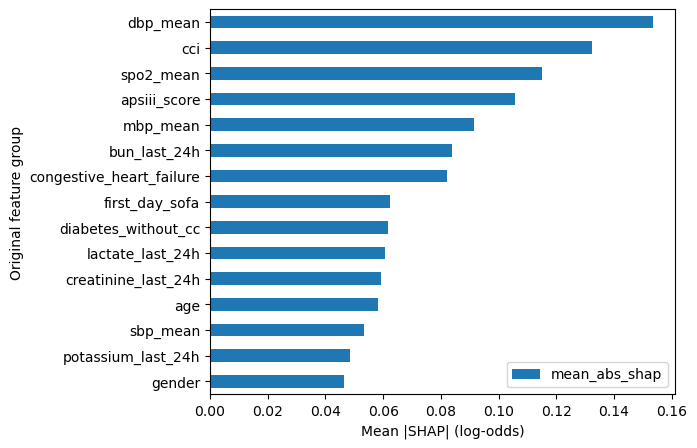

In [203]:
sv, per_feat, grouped, meta = explain_mlp_with_shap(
    model_focal2_1,
    preproc_focal2_1,
    test_df,
    numeric_cols, categorical_cols,
    background_size=512,
    eval_size=200,
    use_logit_link=True,
    random_state=RANDOM_STATE
)


display(grouped.head(15))      # top groups (age, OASIS, cohort, etc.)
display(per_feat.head(25))     # top one-hot levels and numeric features




Text(0.5, 1.0, 'SHAP for MLP trained with focal loss')

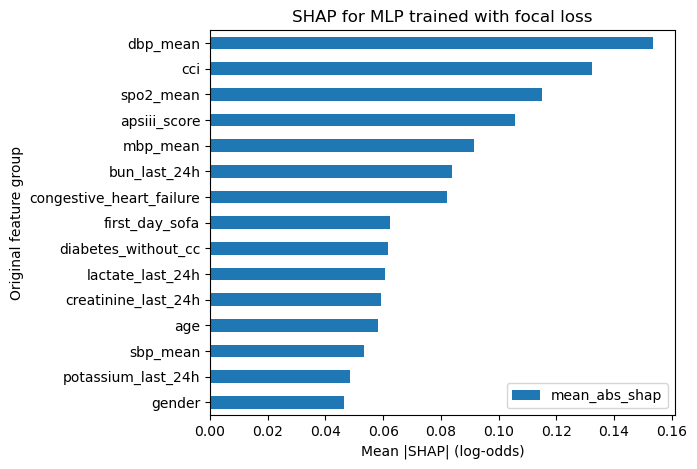

In [281]:
# Optional: quick plot for grouped importances
ax = grouped.head(15).iloc[::-1].plot(kind="barh", x="group", y="mean_abs_shap", figsize=(6,5))
ax.set_xlabel("Mean |SHAP| (log-odds)"); ax.set_ylabel("Original feature group");
ax.set_title("SHAP for MLP trained with focal loss")

In [196]:
import numpy as np, pandas as pd

def build_group_index_map(feature_names, numeric_cols, categorical_cols):
    """
    Return {base_name: np.array(col_indices)} where base_name is either:
      - exact numeric col name, or
      - the categorical col name grouping all OHE siblings (cat_=...).
    """
    fn2idx = {f:i for i,f in enumerate(feature_names)}
    idx_map = {}

    # numeric features: exact 1:1
    for c in numeric_cols:
        if c in fn2idx:
            idx_map[c] = np.array([fn2idx[c]], dtype=int)

    # categorical: group all OHE columns with prefix "c_"
    for c in categorical_cols:
        pref = f"{c}_"
        idxs = [i for i,f in enumerate(feature_names) if f.startswith(pref)]
        if idxs:  # if not constant/dropped
            idx_map[c] = np.array(idxs, dtype=int)

    # any remaining columns (e.g., if something slipped through)
    covered = set(np.concatenate(list(idx_map.values()))) if idx_map else set()
    for i,f in enumerate(feature_names):
        if i not in covered:
            idx_map[f] = np.array([i], dtype=int)

    return idx_map


def group_abs_shap_safe(feature_names, shap_vals, numeric_cols, categorical_cols):
    """
    Global importance: sum mean(|SHAP|) across OHE siblings per base feature.
    shap_vals: (n_samples_eval, n_features_after_transform)
    """
    idx_map = build_group_index_map(feature_names, numeric_cols, categorical_cols)
    mean_abs = np.mean(np.abs(shap_vals), axis=0)  # per transformed column
    rows = []
    for base, idx in idx_map.items():
        rows.append({
            "base": base,
            "mean_abs_shap": float(mean_abs[idx].sum()),
            "n_transformed": int(len(idx))
        })
    return (pd.DataFrame(rows)
              .sort_values("mean_abs_shap", ascending=False)
              .reset_index(drop=True))


def grouped_mean_abs_shap_safe(shap_vals, groups, feature_names, numeric_cols, categorical_cols):
    """
    Group-level importance: for each group value g in `groups` (len = n_samples_eval),
    compute mean(|SHAP|) within group, then aggregate OHE siblings.
    Returns dict[g] -> DataFrame(sorted).
    """
    groups = np.asarray(groups)
    idx_map = build_group_index_map(feature_names, numeric_cols, categorical_cols)
    out = {}
    for g in np.unique(groups):
        mask = (groups == g)
        per_col = np.mean(np.abs(shap_vals[mask]), axis=0)  # (n_features,)
        rows = []
        for base, idx in idx_map.items():
            rows.append({
                "base": base,
                "mean_abs_shap": float(per_col[idx].sum()),
                "n_transformed": int(len(idx))
            })
        out[g] = (pd.DataFrame(rows)
                    .sort_values("mean_abs_shap", ascending=False)
                    .reset_index(drop=True))
    return out


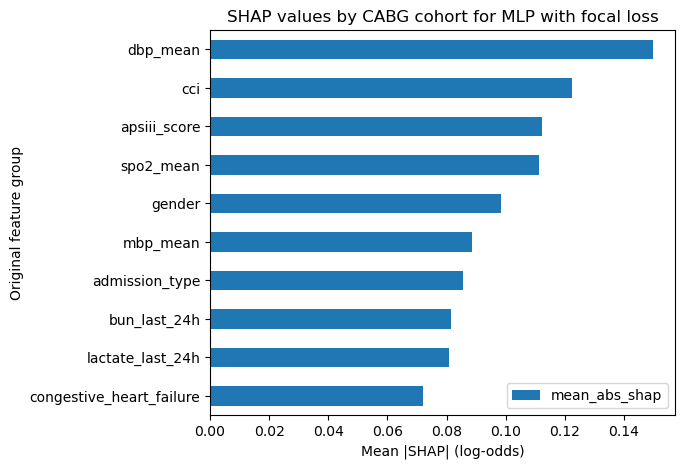

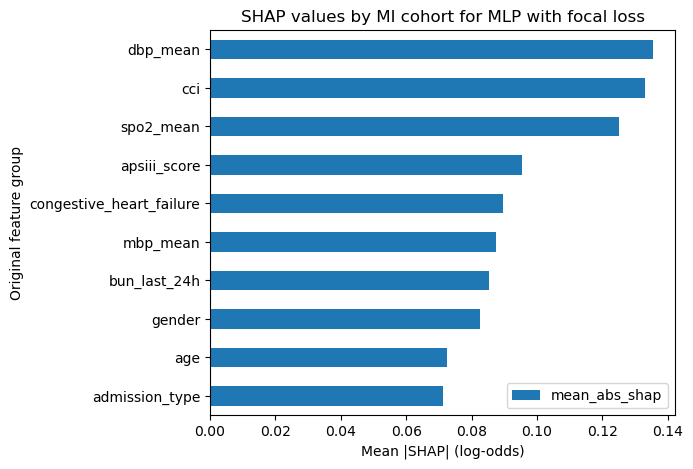

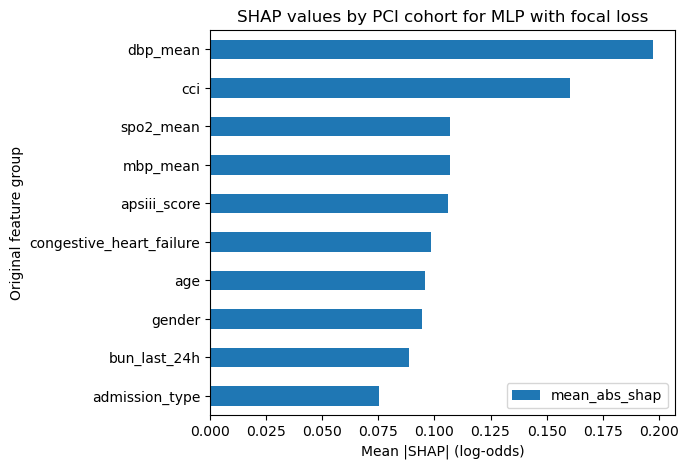

In [282]:
feature_names = meta["feature_names"]

# Global:
global_imp = group_abs_shap_safe(feature_names, sv, numeric_cols, categorical_cols)

eval_idx = meta["eval_indices"]

groups_eval = test_df["cohort"].values[eval_idx]

by_cohort = grouped_mean_abs_shap_safe(
    sv, groups_eval, feature_names, numeric_cols, categorical_cols
)

for cohort in by_cohort.keys():
    # Example: top 10 for MI cohort
    # print(f"SHAP by {cohort} cohort")
    # display(by_cohort[cohort].loc[by_cohort[cohort].base != "cohort",:])
    shap_by_cohort = by_cohort[cohort].loc[by_cohort[cohort].base != "cohort",:]
    ax = shap_by_cohort.head(10).iloc[::-1].plot(kind="barh", x="base", y="mean_abs_shap", figsize=(6,5))
    ax.set_title(f"SHAP values by {cohort} cohort for MLP with focal loss");
    ax.set_xlabel("Mean |SHAP| (log-odds)"); ax.set_ylabel("Original feature group");

#### SHAP based on age group!!!!

In [266]:
_bin_age(test_df.age)

0        60–69
14       60–69
26       50–59
37         80+
40         80+
         ...  
15414    60–69
15415    60–69
15416    60–69
15420     0-49
15431    50–59
Name: age, Length: 2253, dtype: category
Categories (5, object): ['0-49' < '50–59' < '60–69' < '70–79' < '80+']

In [265]:
test_df

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,cohort
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,MI
14,13678189,20731516,33368602,0,1,0,0,61,M,WHITE,...,105.0,147.0,3.4,294.0,10.2,5.1,1.5,1.03,0,MI
26,15156174,27579747,33046466,0,1,0,0,51,M,WHITE,...,10.0,142.0,4.3,107.0,11.7,6.4,NaN,1.14,1,MI
37,17031608,23375584,39314937,0,1,0,0,82,F,WHITE,...,19.0,143.0,4.2,113.0,10.3,7.1,NaN,0.48,0,MI
40,17579498,21787496,30038282,0,1,0,0,82,M,WHITE,...,18.0,137.0,3.8,110.0,11.3,8.7,NaN,1.49,0,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15414,19960105,27042506,38591947,0,0,0,1,65,F,WHITE,...,22.0,137.0,3.8,90.0,7.8,6.3,NaN,NaN,1,CABG
15415,19960105,27042506,36134835,0,0,0,1,65,F,WHITE,...,60.0,143.0,5.3,127.0,10.9,9.9,NaN,NaN,2,CABG
15416,19963068,20111271,34132866,0,0,0,1,69,M,AMERICAN INDIAN/ALASKA NATIVE,...,60.0,139.0,5.9,74.0,12.3,9.7,1.1,NaN,0,CABG
15420,19966568,25640873,32059064,0,0,0,1,42,M,WHITE,...,9.0,134.0,4.3,87.0,13.4,11.2,4.4,NaN,0,CABG


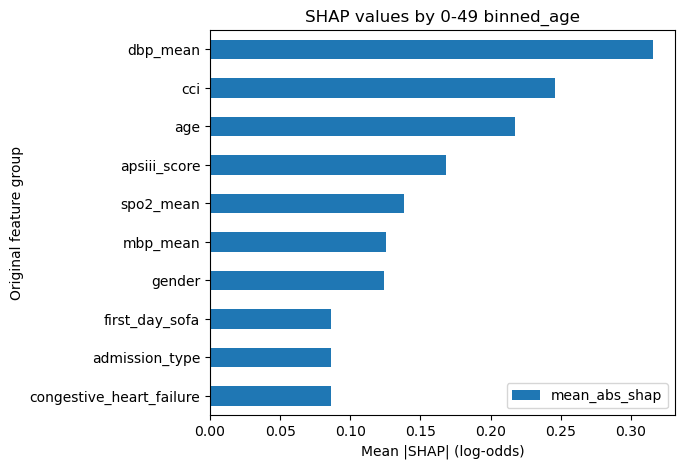

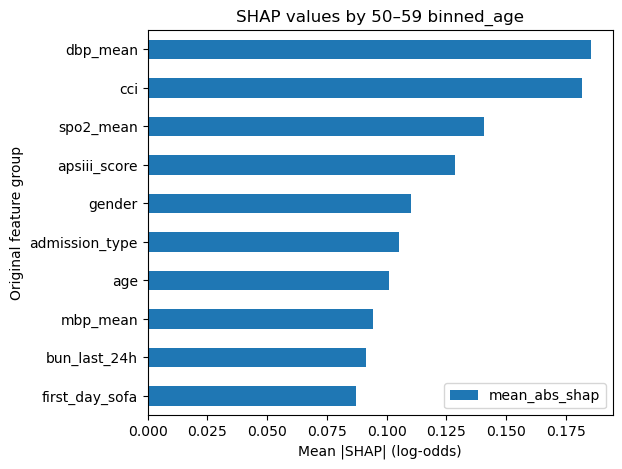

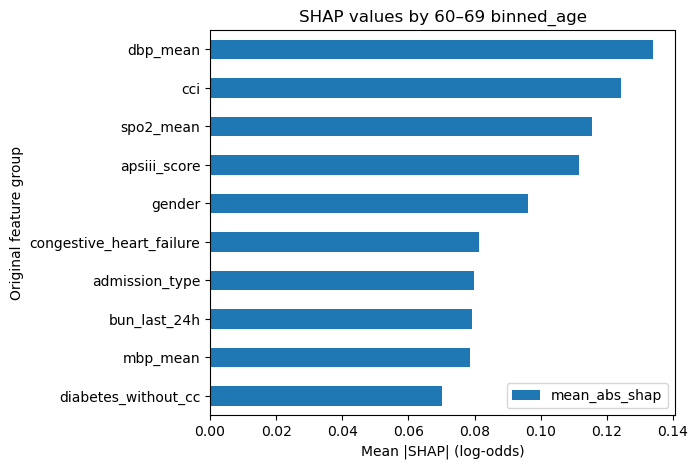

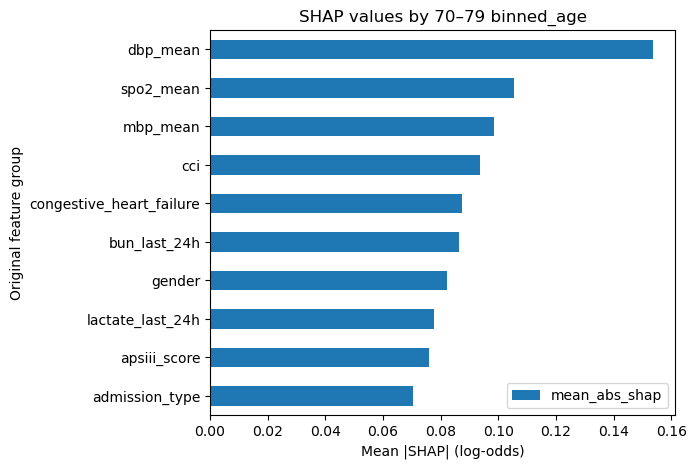

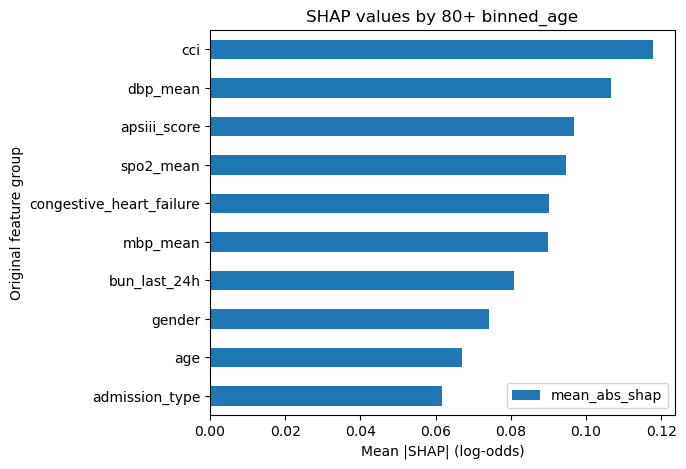

In [267]:
feature_names = meta["feature_names"]


eval_idx = meta["eval_indices"]

eval_col = "binned_age"

test_df[eval_col] = _bin_age(test_df.age)

groups_eval = test_df[eval_col].values[eval_idx]

by_cohort = grouped_mean_abs_shap_safe(
    sv, groups_eval, feature_names, numeric_cols, categorical_cols
)

for cohort in by_cohort.keys():
    # Example: top 10 for MI cohort
    # print(f"SHAP by {cohort} cohort")
    # display(by_cohort[cohort].loc[by_cohort[cohort].base != "cohort",:])
    shap_by_cohort = by_cohort[cohort].loc[by_cohort[cohort].base != "cohort",:]
    ax = shap_by_cohort.head(10).iloc[::-1].plot(kind="barh", x="base", y="mean_abs_shap", figsize=(6,5))
    ax.set_title(f"SHAP values by {cohort} {eval_col}");
    ax.set_xlabel("Mean |SHAP| (log-odds)"); ax.set_ylabel("Original feature group");

#### SHAP by race

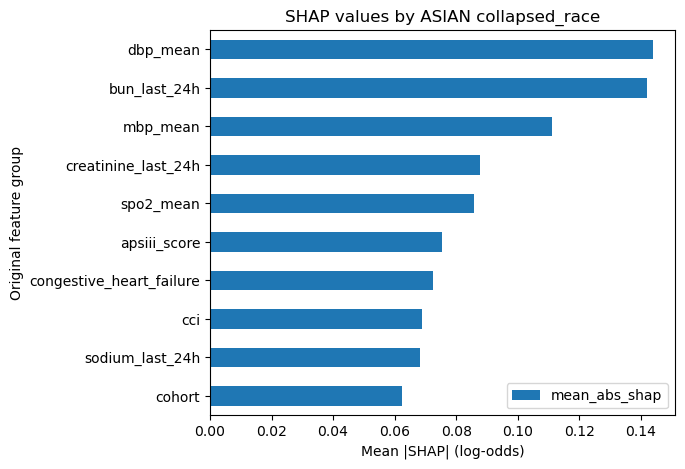

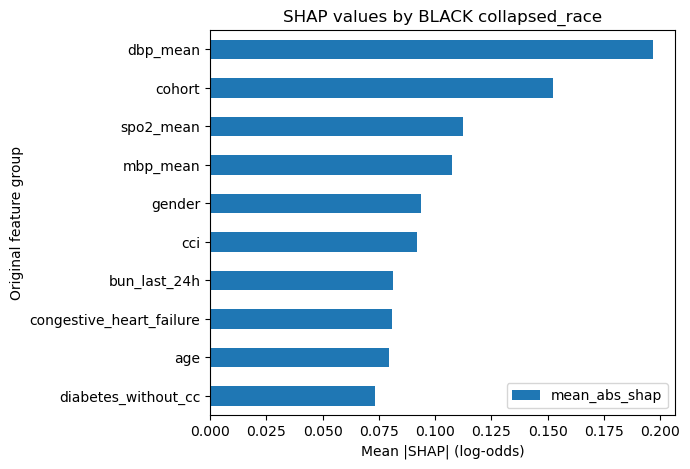

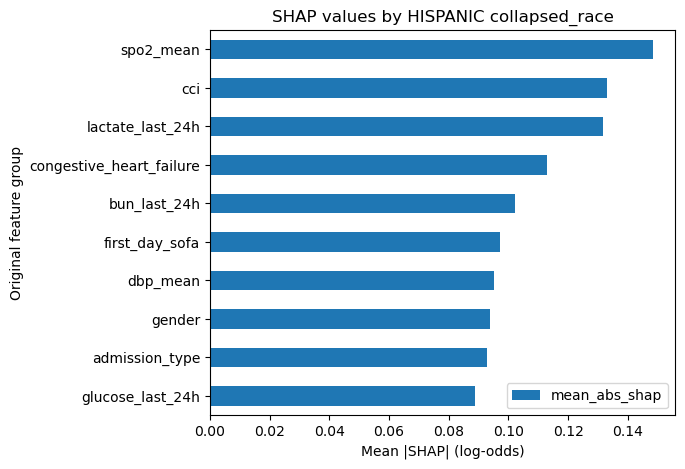

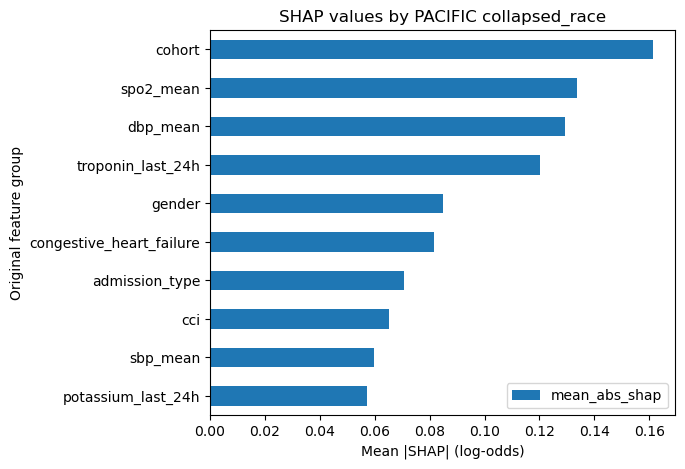

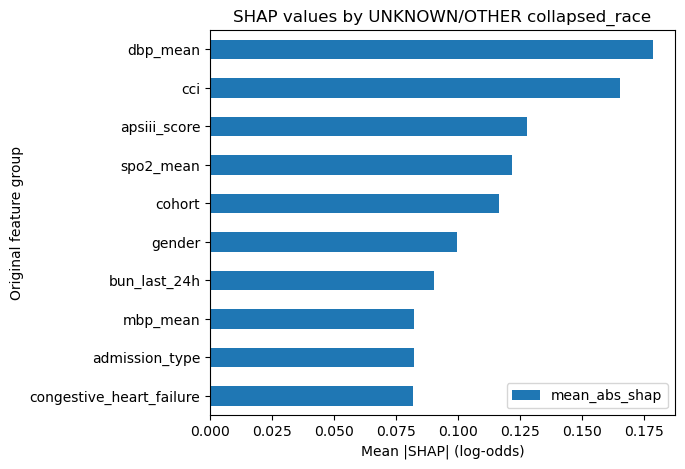

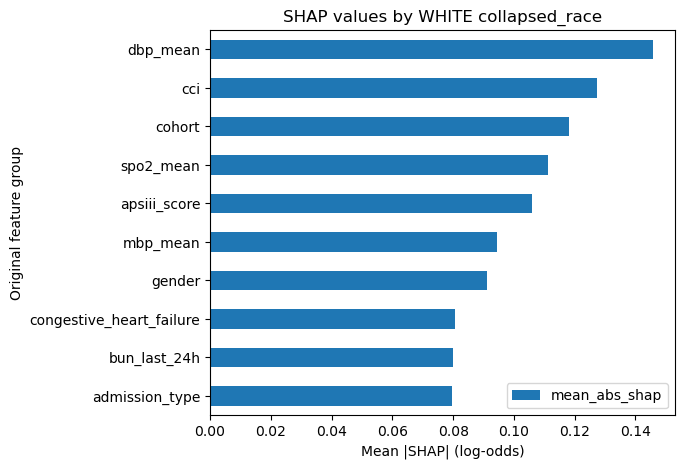

In [296]:
feature_names = meta["feature_names"]


eval_idx = meta["eval_indices"]

eval_col = "collapsed_race"
test_df[eval_col] = df["race"].map(collapse_race)

groups_eval = test_df[eval_col].values[eval_idx]

by_cohort = grouped_mean_abs_shap_safe(
    sv, groups_eval, feature_names, numeric_cols, categorical_cols
)

for cohort in by_cohort.keys():
    # Example: top 10 for MI cohort
    # print(f"SHAP by {cohort} cohort")
    # display(by_cohort[cohort].loc[by_cohort[cohort].base != "cohort",:])
    shap_by_cohort = by_cohort[cohort]
    ax = shap_by_cohort.head(10).iloc[::-1].plot(kind="barh", x="base", y="mean_abs_shap", figsize=(6,5))
    ax.set_title(f"SHAP values by {cohort} {eval_col}");
    ax.set_xlabel("Mean |SHAP| (log-odds)"); ax.set_ylabel("Original feature group");

## Grouped histogram of predicted probabilities split by actual outcome

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pred_prob_hist(test_df, pre, model, bins=50, want_kde=False, thresh=None, model_desc=""):

    # ---- transform test ----
    ID_COLS = ["subject_id", "hadm_id", "stay_id", "is_mi", "is_pcr", "is_cbs"]
    DROP_COLS_TEST = [c for c in (ID_COLS + ["y"]) if c in test_df.columns]
    Xte_raw = test_df.drop(columns=DROP_COLS_TEST)
    yte = test_df["y"].to_numpy().astype("int32")
    Xte = pre.transform(Xte_raw).astype("float32")

    # ---- continuous metrics ----
    proba_te = model.predict(Xte, verbose=0).ravel()
    # aucpr_te = average_precision_score(yte, proba_te)
    # aucroc_te = roc_auc_score(yte, proba_te)
    # print(f"Test AUC-PR = {aucpr_te:.3f} | Test ROC-AUC = {aucroc_te:.3f}")
    
    plt.figure(figsize=(8,5))
    sns.histplot(proba_te[yte==0], color="skyblue", bins=bins, label="No Readmission", kde=want_kde, stat="probability")
    sns.histplot(proba_te[yte==1], color="orange", bins=bins, label="Readmission", kde=want_kde, stat="probability")
    plt.xlabel("Predicted Probability (Readmission)")
    plt.ylabel("Density")
    
    if thresh is not None:
        plt.vlines(thresh, 0, 0.15, linestyles="dotted", colors="k")
    
    plt.title(f"Distribution of Predicted Probabilities by Actual Outcome in Test Set\n({model_desc})")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Vanilla

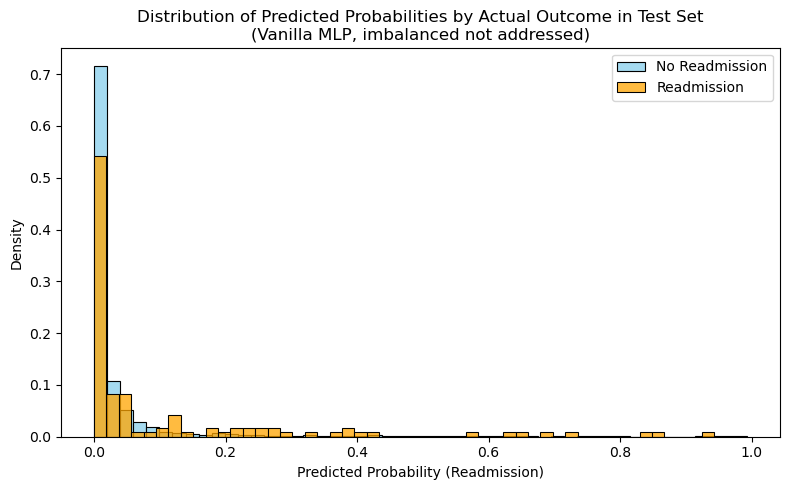

In [275]:
plot_pred_prob_hist(test_df, preproc_vanilla, model_vanilla, bins=50, model_desc="Vanilla MLP, imbalanced not addressed")

### Resampling

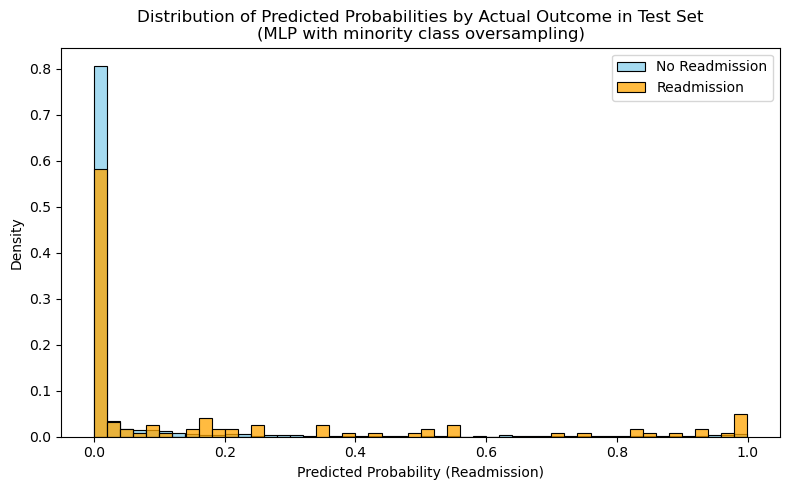

In [276]:
plot_pred_prob_hist(test_df, preproc_os, model_os, bins=50, model_desc="MLP with minority class oversampling")

### Focal V2

$\gamma$ parameter in focal loss optimizes classification, but not probability accuracy (almost clear separation but the scale is clearly compressed)

MENTION THE CLEAR REMARK THAT PROBABILITIES ARE NOT CALIBRATED

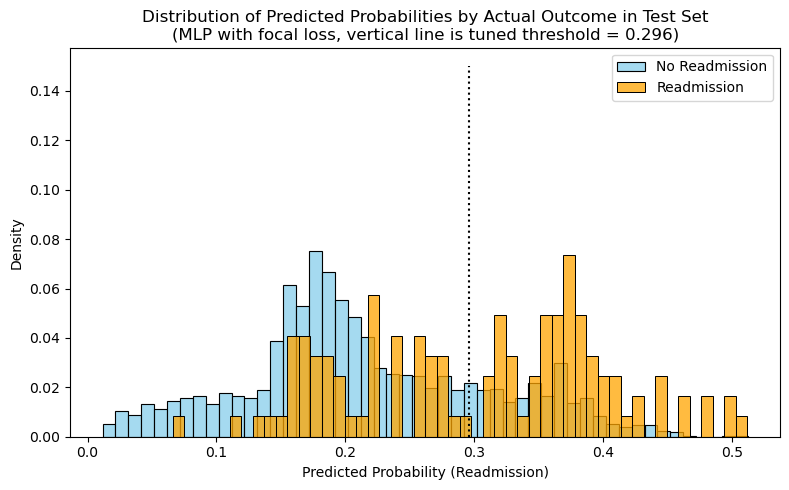

In [279]:
plot_pred_prob_hist(test_df, preproc_focal2_1, model_focal2_1, bins=50, thresh=tau_star, model_desc=f"MLP with focal loss, vertical line is tuned threshold = {tau_star:.3f}")

<Axes: >

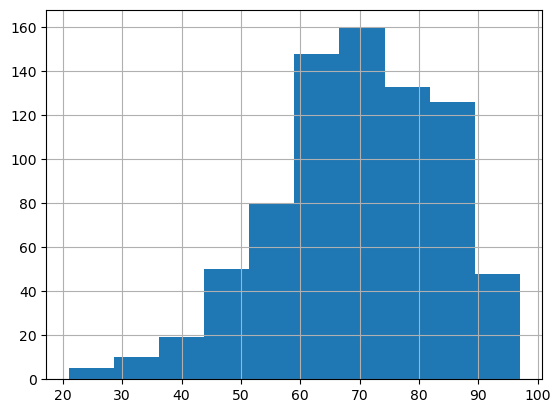

In [263]:
test_df[test_df.cohort == "MI"].age.hist()